<a href="https://colab.research.google.com/github/mcn3159/ANBB_resistance_rates/blob/main/traintest_atp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
from collections import Counter
import gc
import math
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.nn import functional as F
from torch.distributions import Normal, kl_divergence

warnings.filterwarnings('ignore', category=UserWarning)

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Colab-friendly data path discovery. Edit DATA_DIR manually if needed.
CANDIDATE_DATA_DIRS = [
    Path('/Users/mn3159/Downloads/StewardGuard/generating_antibiograms/armd_datasets'),
    Path('/content/armd_datasets'),
    Path('/content/drive/MyDrive/armd_datasets'),
    Path('/Users/mn3159/bigpurple/scratch/mn3159/generate_antibiogram')
]
DATA_DIR = next((p for p in CANDIDATE_DATA_DIRS if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find armd_datasets. Put the folder beside this notebook, '
        'or mount Google Drive and set DATA_DIR to the folder path.'
    )

df_path = DATA_DIR / 'combined_armd.tsv'

TEST_SITE = 'UTSW'
TRAIN_SITES = ['ECUH', 'Stanford']


FORECAST_HORIZON_MONTHS = 12
# Monthly rows with very small denominators are noisy. They are kept in the raw
# biogram table but excluded from ANP contexts/training episodes.
MIN_MONTHLY_TESTS = 5
MIN_CONTEXT_POINTS = 6
MIN_SERIES_POINTS_FOR_TRAINING = 18
MAX_CONTEXT_POINTS = 12
MAX_TARGET_POINTS = FORECAST_HORIZON_MONTHS

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'DATA_DIR: {DATA_DIR.resolve()}')
print(f'Device: {DEVICE}')


DATA_DIR: /content/drive/.shortcut-targets-by-id/1BLkwKaBzxi1YI74CPtJcnp7-X3nS6qIk/armd_datasets
Device: cuda


In [3]:
df = pd.read_csv(df_path,sep="\t")
df

,site,year,month,year_month,month_start,organism,antibiotic,tested_count,resistant_count,Resistant,culture_description
0,ECUH,2014,11,2014-11,2014-11-01,ENTEROBACTER AEROGENES,AMP/SULBACTAM,1,1,1.00,URINE
1,ECUH,2014,11,2014-11,2014-11-01,ENTEROBACTER AEROGENES,AMPICILLIN,3,3,1.00,URINE
2,ECUH,2014,11,2014-11,2014-11-01,ENTEROBACTER AEROGENES,CIPROFLOXACIN,3,0,0.00,URINE
3,ECUH,2014,11,2014-11,2014-11-01,ENTEROBACTER AEROGENES,DORIPENEM,3,0,0.00,URINE
4,ECUH,2014,11,2014-11,2014-11-01,ENTEROBACTER AEROGENES,ERTAPENEM,3,0,0.00,URINE
...,...,...,...,...,...,...,...,...,...,...,...
388998,UTSW,2025,2,2025-02,2025-02-01,STAPHYLOCOCCUS EPIDERMIDIS,TRIMETHOPRIM/SULFAMETHOXAZOLE,4,3,0.75,URINE
388999,UTSW,2025,2,2025-02,2025-02-01,STAPHYLOCOCCUS EPIDERMIDIS,VANCOMYCIN,4,0,0.00,URINE
389000,UTSW,2025,2,2025-02,2025-02-01,STREPTOCOCCUS MITIS ORALIS GROUP,AMPICILLIN,1,0,0.00,BLOOD
389001,UTSW,2025,2,2025-02,2025-02-01,STREPTOCOCCUS MITIS ORALIS GROUP,CEFTRIAXONE,1,0,0.00,BLOOD


In [4]:
sp_name_mapper_path = "/content/drive/MyDrive/species_canonical_mapping.tsv"
sp_name_mapper = pd.read_csv(sp_name_mapper_path,sep="\t")
display(sp_name_mapper.head())
sp_name_mapper = dict(zip(sp_name_mapper['Original name'],sp_name_mapper['Canonical name']))
df.replace(sp_name_mapper,inplace=True)



,Original name,Canonical name
0,MYCOBACTERIUM AVIUM COMPLEX BY DNA PROBE,MYCOBACTERIUM AVIUM COMPLEX
1,MYCOBACTERIUM FORTUITUM SPECIES GROUP,MYCOBACTERIUM FORTUITUM SPECIES GROUP
2,MIXED GENITAL FLORA,MIXED GENITAL FLORA
3,GROUP G BETA STREPTOCOCCUS,GROUP G BETA STREPTOCOCCUS
4,GRAM NEGATIVE RODS AND GRAM POSITIVE COCCI,GRAM NEGATIVE RODS AND GRAM POSITIVE COCCI


In [5]:
biogram = df.copy()

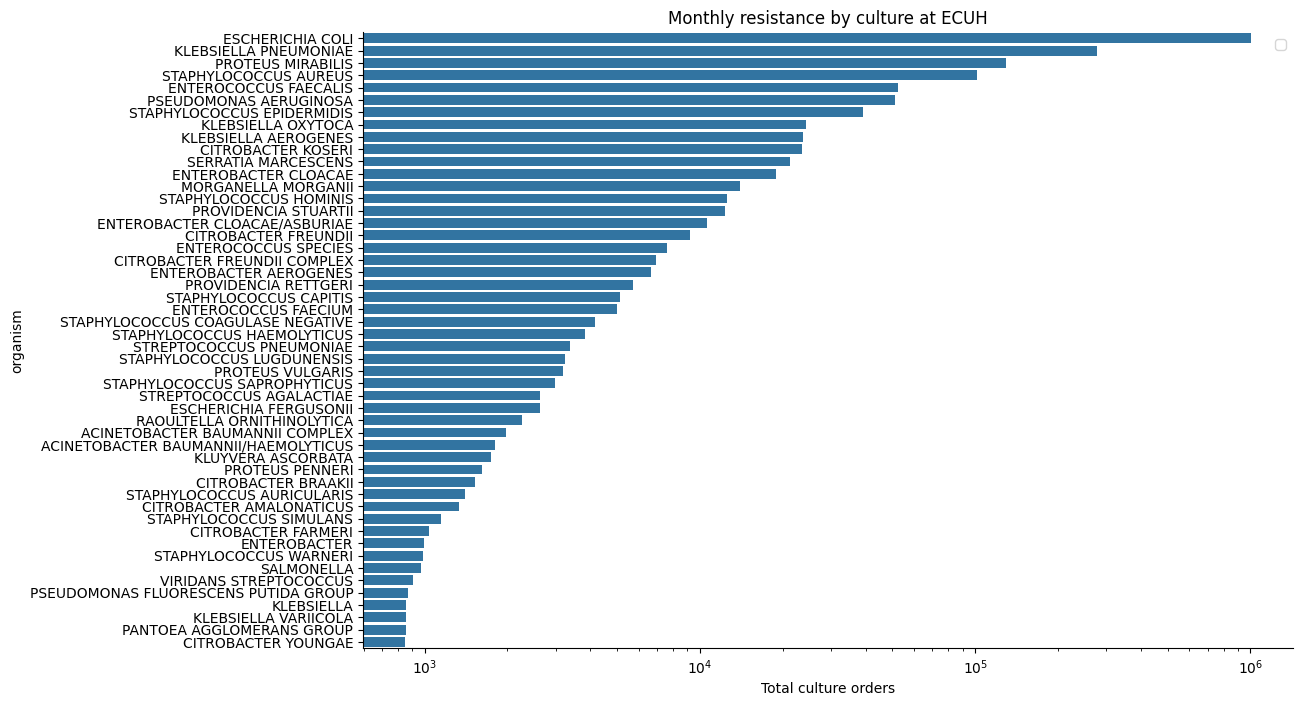

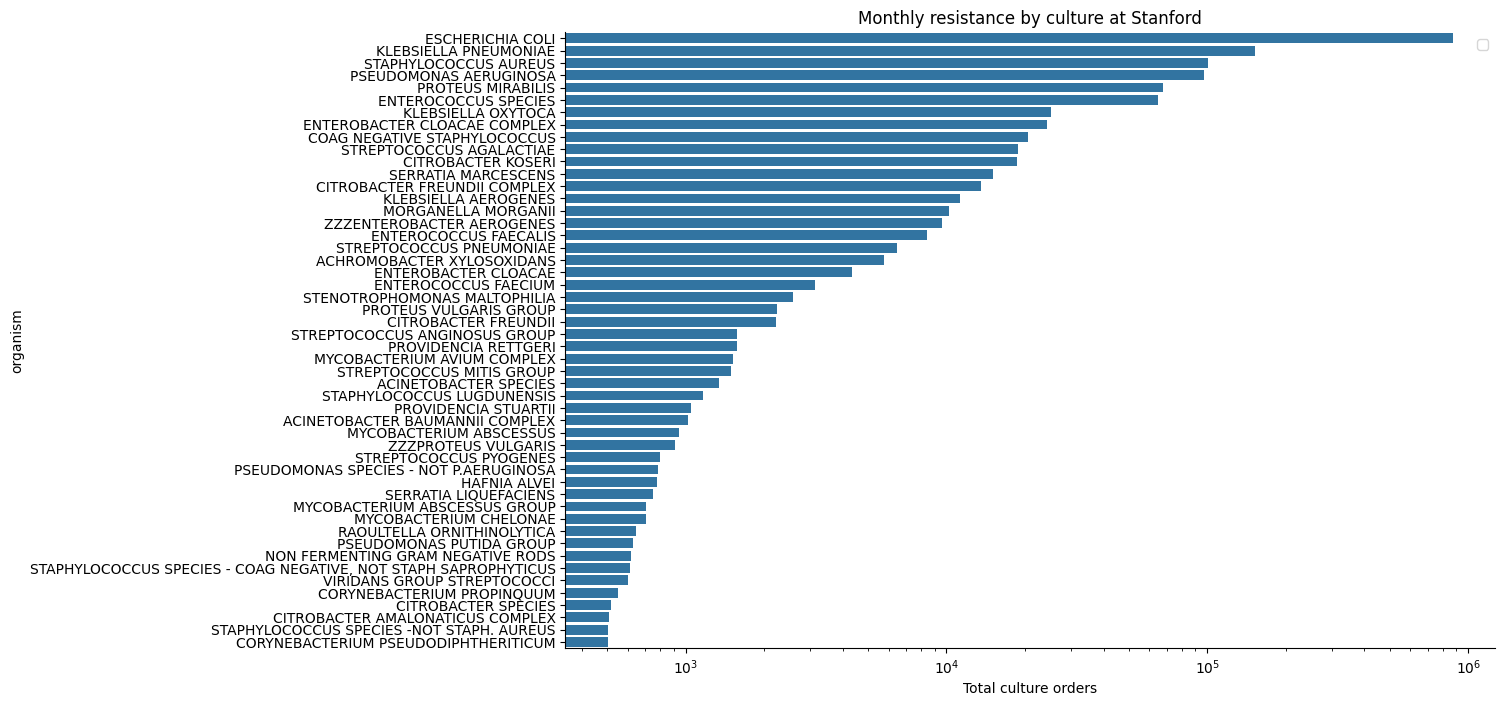

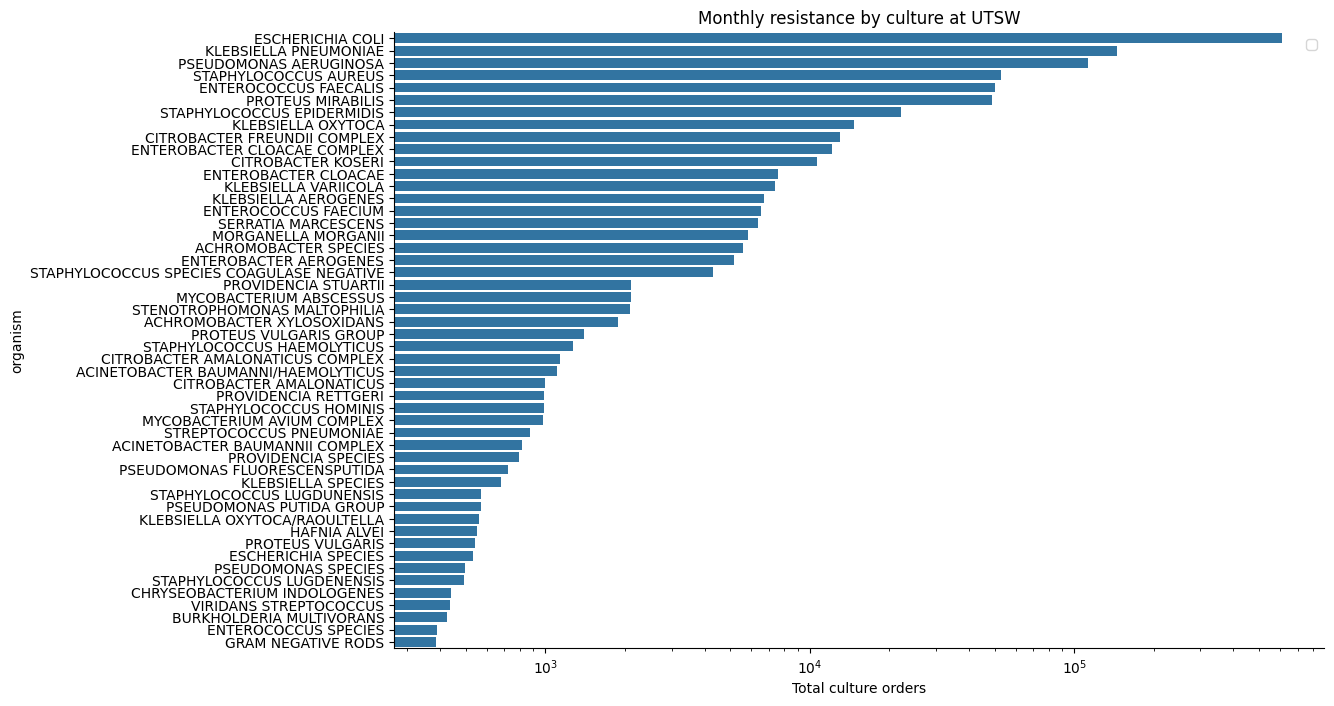

In [6]:
biogram_sub = biogram.groupby(['organism','site'],as_index=False)['tested_count'].sum().sort_values(by='tested_count',ascending=False)

n = 50
for site in set(biogram_sub['site']):
    fig, ax = plt.subplots(figsize=(12, 8))
    biogram_sub_sub = biogram_sub[biogram_sub['site']==site].copy()
    biogram_sub_sub.drop_duplicates(subset='organism',inplace=True)
    sns.barplot(biogram_sub_sub.iloc[:n,:],x='tested_count',y='organism',ax=ax)
    ax.set_title(f'Monthly resistance by culture at {site}')
    ax.set_xlabel('Total culture orders')
    # ax.set_xticks(fontsize=10)
    ax.set_xscale('log')
    ax.legend()
    plt.show()

In [7]:
biogram['organism'] = biogram['organism'].str.replace('ZZZ','')
biogram['organism'] = biogram['organism'].str.split(' SUBSP').str[0]
biogram.loc[(biogram['organism'].str.contains('COAG')) & (biogram['organism'].str.contains('NEG')),'organism'] = 'STAPHYLOCOCCUS SPECIES COAGULASE NEGATIVE'
biogram['organism'] = biogram['organism'].str.split('/').str[0]
biogram.loc[biogram['organism'] == 'ACINETOBACTER BAUMANNI','organism'] = 'ACINETOBACTER BAUMANNII'
biogram.loc[biogram['organism'] == 'PROTEUS VULGARIS GROUP','organism'] = 'PROTEUS VULGARIS'



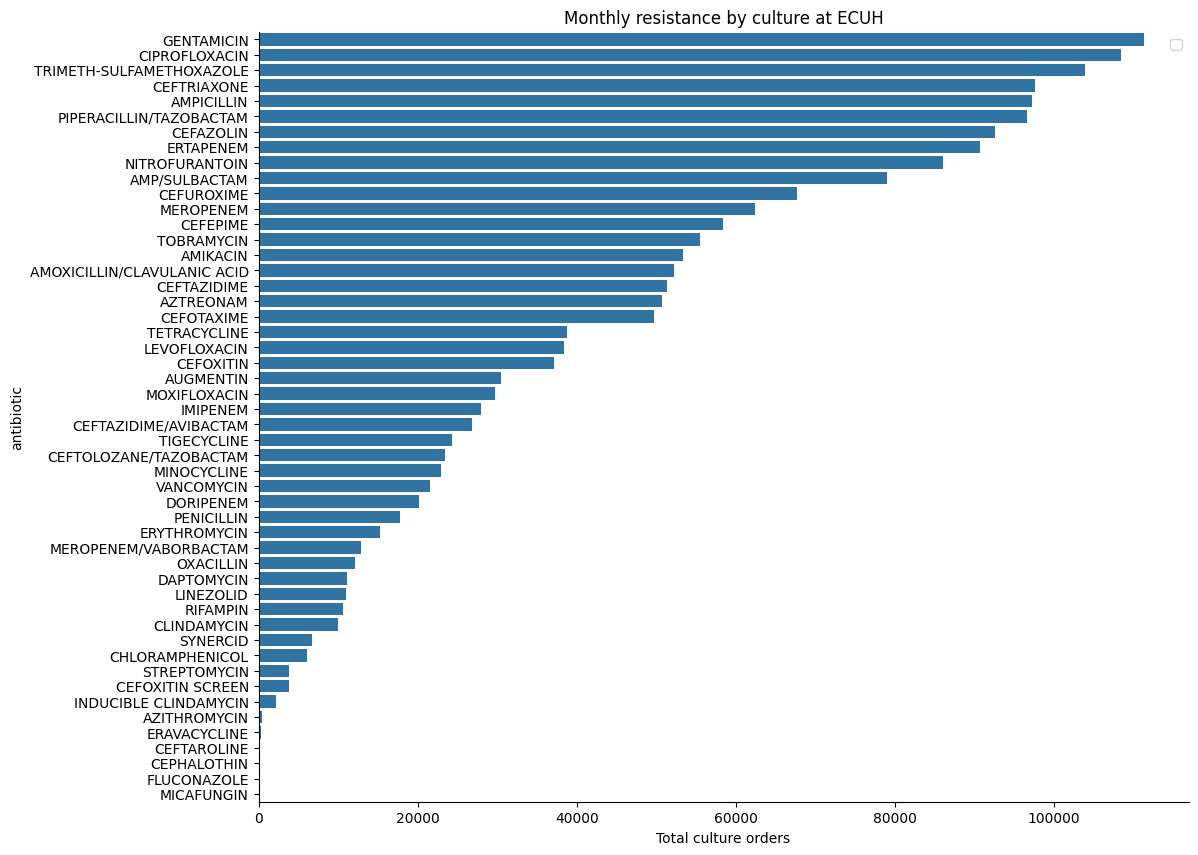

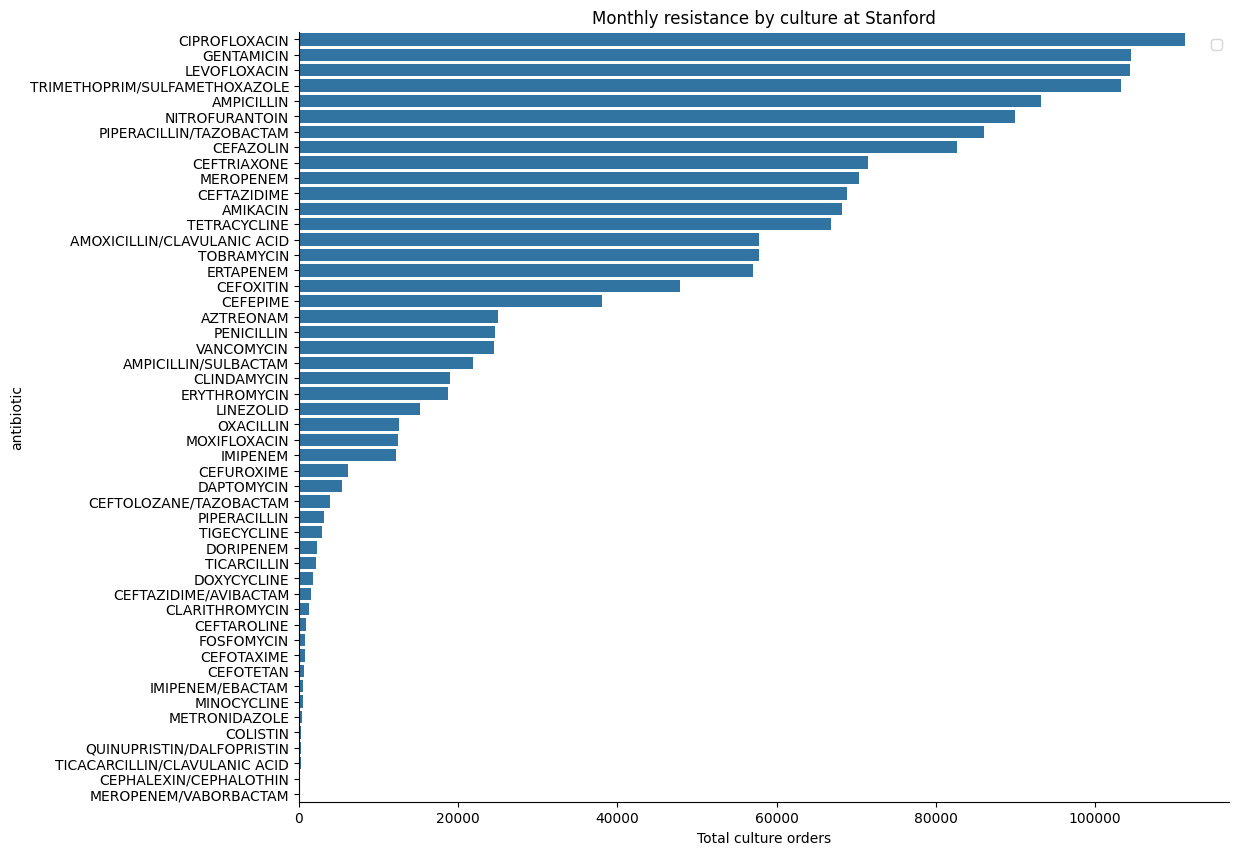

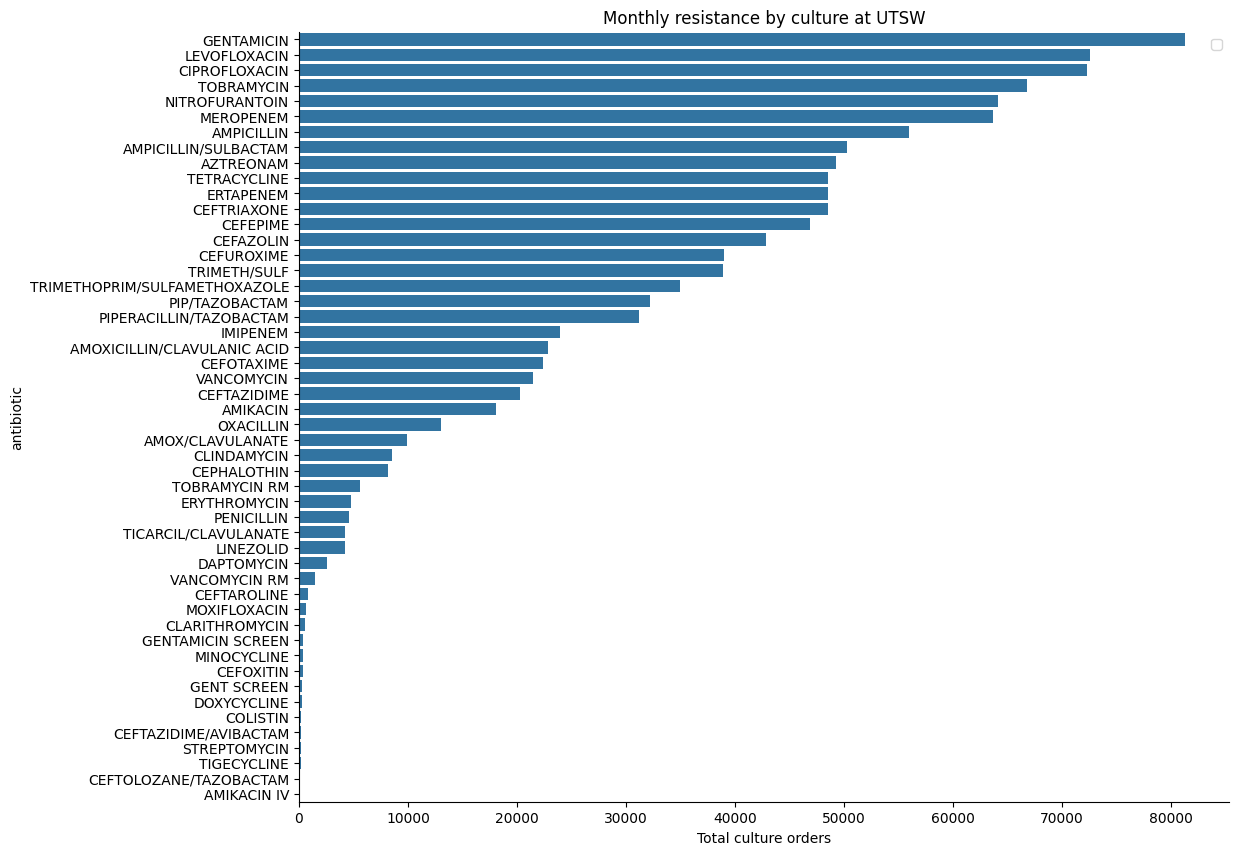

In [8]:
biogram_sub = biogram.groupby(['antibiotic','site'],as_index=False)['tested_count'].sum().sort_values(by='tested_count',ascending=False)

n = 50
for site in set(biogram_sub['site']):
    fig, ax = plt.subplots(figsize=(12, 10))
    biogram_sub_sub = biogram_sub[biogram_sub['site']==site].copy()
    biogram_sub_sub.drop_duplicates(subset='antibiotic',inplace=True)
    sns.barplot(biogram_sub_sub.iloc[:n,:],x='tested_count',y='antibiotic',ax=ax)
    ax.set_title(f'Monthly resistance by culture at {site}')
    ax.set_xlabel('Total culture orders')
    # ax.set_xticks(fontsize=10)
    ax.legend()
    plt.show()

In [9]:
print(biogram[biogram['antibiotic'].str.contains('TRIMETH')].drop_duplicates(subset='antibiotic')['antibiotic'].to_list())
biogram.loc[biogram['antibiotic'].str.contains('TRIMETH'),'antibiotic'] = 'TRIMETHOPRIM/SULFAMETHOXAZOLE'
biogram.loc[biogram['antibiotic']=='AMP/SULBACTAM','antibiotic'] = 'AMPICILLIN/SULBACTAM'
biogram.loc[biogram['antibiotic']=='PIP/TAZOBACTAM','antibiotic'] = 'PIPERACILLIN/TAZOBACTAM'
biogram.loc[biogram['antibiotic'].str.contains('AMOX'),'antibiotic'] = 'AMOXICILLIN/CLAVULANIC ACID'
biogram['antibiotic'] = biogram['antibiotic'].str.split(' RM').str[0]
biogram.loc[biogram['antibiotic']=='INDUCIBLE CLINDAMYCIN','antibiotic'] = 'CLINDAMYCIN'



['TRIMETH-SULFAMETHOXAZOLE', 'TRIMETHOPRIM/SULFAMETHOXAZOLE', 'TRIMETH/SULF']


In [10]:
biogram = biogram.groupby(['year_month','organism','antibiotic','culture_description','site'])[['tested_count','resistant_count']].sum().reset_index() # purposely left out culture counts on next next cell
biogram['year'],biogram['month'] = biogram['year_month'].str.split('-').str[0],biogram['year_month'].str.split('-').str[-1]
biogram['month_start'] = pd.to_datetime(biogram['year_month'])
biogram['Resistant'] = biogram['resistant_count'] / biogram['tested_count']
biogram

,year_month,organism,antibiotic,culture_description,site,tested_count,resistant_count,year,month,month_start,Resistant
0,2006-04,ACINETOBACTER BAUMANNII,AMOXICILLIN/CLAVULANIC ACID,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000
1,2006-04,ACINETOBACTER BAUMANNII,AMPICILLIN,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000
2,2006-04,ACINETOBACTER BAUMANNII,CEFEPIME,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000
3,2006-04,ACINETOBACTER BAUMANNII,CEFOTAXIME,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000
4,2006-04,ACINETOBACTER BAUMANNII,CEFTAZIDIME,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
370214,2025-02,STREPTOCOCCUS PYOGENES,CEFTRIAXONE,BLOOD,ECUH,3,0,2025,02,2025-02-01,0.000000
370215,2025-02,STREPTOCOCCUS PYOGENES,CLINDAMYCIN,BLOOD,ECUH,3,1,2025,02,2025-02-01,0.333333
370216,2025-02,STREPTOCOCCUS PYOGENES,ERYTHROMYCIN,BLOOD,ECUH,3,1,2025,02,2025-02-01,0.333333
370217,2025-02,STREPTOCOCCUS PYOGENES,PENICILLIN,BLOOD,ECUH,3,0,2025,02,2025-02-01,0.000000


In [11]:
# test = df[(df['year_month']=='2025-02') & (df['organism']=='STREPTOCOCCUS PYOGENES')]
# display(test)
# test.groupby('organism')[['tested_count','resistant_count']].sum().reset_index()


In [12]:
min_abx_tests = 500
abx_to_keep = biogram.groupby('antibiotic')['tested_count'].sum()
abx_to_keep = abx_to_keep[abx_to_keep>=min_abx_tests].index.to_list()
print("Total antibiotics:",len(abx_to_keep))

min_organisms = 1000
bugs_to_keep = biogram.groupby('organism')['tested_count'].sum()
bugs_to_keep = bugs_to_keep[bugs_to_keep>=min_organisms].index.to_list()
print("Total bugs:",len(bugs_to_keep))

biogram = biogram[(biogram['organism'].isin(bugs_to_keep)) & (biogram['antibiotic'].isin(abx_to_keep))]
biogram

Total antibiotics: 54
Total bugs: 59


,year_month,organism,antibiotic,culture_description,site,tested_count,resistant_count,year,month,month_start,Resistant
0,2006-04,ACINETOBACTER BAUMANNII,AMOXICILLIN/CLAVULANIC ACID,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000
1,2006-04,ACINETOBACTER BAUMANNII,AMPICILLIN,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000
2,2006-04,ACINETOBACTER BAUMANNII,CEFEPIME,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000
3,2006-04,ACINETOBACTER BAUMANNII,CEFOTAXIME,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000
4,2006-04,ACINETOBACTER BAUMANNII,CEFTAZIDIME,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
370214,2025-02,STREPTOCOCCUS PYOGENES,CEFTRIAXONE,BLOOD,ECUH,3,0,2025,02,2025-02-01,0.000000
370215,2025-02,STREPTOCOCCUS PYOGENES,CLINDAMYCIN,BLOOD,ECUH,3,1,2025,02,2025-02-01,0.333333
370216,2025-02,STREPTOCOCCUS PYOGENES,ERYTHROMYCIN,BLOOD,ECUH,3,1,2025,02,2025-02-01,0.333333
370217,2025-02,STREPTOCOCCUS PYOGENES,PENICILLIN,BLOOD,ECUH,3,0,2025,02,2025-02-01,0.000000


In [13]:
import dask.dataframe as dd
df_chunks_path = DATA_DIR / "inpatient__icd10_cap_uti_skin__meds.tsv" # same as inpatient__icd10_cap_uti_skin__meds
caputiskin_meds = dd.read_csv(df_chunks_path, sep="\t",low_memory=False).compute().reset_index(drop=True).iloc[:,1:]
caputiskin_meds = caputiskin_meds[['MEDICATION_NAME', 'GENERIC_NAME', 'PHARM_CLASS', 'PHARM_SUBCLASS']]
#try concat 1-hot encode, then learned embed, predict PHARM_CLASS?
caputiskin_meds.drop_duplicates(inplace=True)
caputiskin_meds

,MEDICATION_NAME,GENERIC_NAME,PHARM_CLASS,PHARM_SUBCLASS
0,AZITHROMYCIN 500 MG IN 250ML NS,<NA>,MACROLIDE ANTIBIOTICS,Macrolide Antibiotics
1,SULFAMETHOXAZOLE 800 MG-TRIMETHOPRIM 160 MG TA...,sulfamethoxazole 800 mg-trimethoprim 160 mg ta...,ABSORBABLE SULFONAMIDE ANTIBACTERIAL AGENTS,Antibacterial Folate Antagonist - Other Combin...
2,LEVOFLOXACIN 750 MG TABLET,levoFLOXacin 750 mg tablet,QUINOLONE ANTIBIOTICS,Fluoroquinolone Antibiotics
3,DOXYCYCLINE HYCLATE 100 MG TABLET,doxycycline hyclate 100 mg tablet,TETRACYCLINE ANTIBIOTICS,Tetracycline Antibiotics
4,CEFADROXIL 500 MG CAPSULE,cefadroxil 500 mg capsule,CEPHALOSPORIN ANTIBIOTICS - 1ST GENERATION,Cephalosporin Antibiotics - 1st Generation
...,...,...,...,...
418038,CEFTAZIDIME IN LIDOCAINE 1% - PHARMACY COMPOUN...,cefTAZidime 1 gram solution for injection,CEPHALOSPORIN ANTIBIOTICS - 3RD GENERATION,Cephalosporin Antibiotics - 3rd Generation
422104,CEFTAZIDIME 1 GRAM SOLUTION FOR INJECTION,cefTAZidime 1 gram solution for injection,CEPHALOSPORIN ANTIBIOTICS - 3RD GENERATION,Cephalosporin Antibiotics - 3rd Generation
440030,UREX (METHENAMINE) ORAL,methenamine hippurate oral,"ANTIBIOTIC, ANTIBACTERIAL, MISC.",Misc Anti-Infective
442749,RIFAMPIN ORAL,rifampin oral,ANTITUBERCULAR ANTIBIOTICS,Antitubercular - Rifamycin and Derivatives


In [14]:
valix_abx_names = set(' '.join(biogram['antibiotic'].dropna()).split())
valix_abx_names.update(set(' '.join(biogram['antibiotic'].dropna()).split('/')))

caputiskin_meds['MEDICATION_NAME_filtered'] = caputiskin_meds['MEDICATION_NAME'].dropna().apply(
    lambda x: ' '.join(w for w in x.split() if w in valix_abx_names)
)
caputiskin_meds

,MEDICATION_NAME,GENERIC_NAME,PHARM_CLASS,PHARM_SUBCLASS,MEDICATION_NAME_filtered
0,AZITHROMYCIN 500 MG IN 250ML NS,<NA>,MACROLIDE ANTIBIOTICS,Macrolide Antibiotics,
1,SULFAMETHOXAZOLE 800 MG-TRIMETHOPRIM 160 MG TA...,sulfamethoxazole 800 mg-trimethoprim 160 mg ta...,ABSORBABLE SULFONAMIDE ANTIBACTERIAL AGENTS,Antibacterial Folate Antagonist - Other Combin...,
2,LEVOFLOXACIN 750 MG TABLET,levoFLOXacin 750 mg tablet,QUINOLONE ANTIBIOTICS,Fluoroquinolone Antibiotics,LEVOFLOXACIN
3,DOXYCYCLINE HYCLATE 100 MG TABLET,doxycycline hyclate 100 mg tablet,TETRACYCLINE ANTIBIOTICS,Tetracycline Antibiotics,DOXYCYCLINE
4,CEFADROXIL 500 MG CAPSULE,cefadroxil 500 mg capsule,CEPHALOSPORIN ANTIBIOTICS - 1ST GENERATION,Cephalosporin Antibiotics - 1st Generation,
...,...,...,...,...,...
418038,CEFTAZIDIME IN LIDOCAINE 1% - PHARMACY COMPOUN...,cefTAZidime 1 gram solution for injection,CEPHALOSPORIN ANTIBIOTICS - 3RD GENERATION,Cephalosporin Antibiotics - 3rd Generation,CEFTAZIDIME
422104,CEFTAZIDIME 1 GRAM SOLUTION FOR INJECTION,cefTAZidime 1 gram solution for injection,CEPHALOSPORIN ANTIBIOTICS - 3RD GENERATION,Cephalosporin Antibiotics - 3rd Generation,CEFTAZIDIME
440030,UREX (METHENAMINE) ORAL,methenamine hippurate oral,"ANTIBIOTIC, ANTIBACTERIAL, MISC.",Misc Anti-Infective,
442749,RIFAMPIN ORAL,rifampin oral,ANTITUBERCULAR ANTIBIOTICS,Antitubercular - Rifamycin and Derivatives,RIFAMPIN


In [15]:
# print(caputiskin_meds[caputiskin_meds['MEDICATION_NAME'].str.contains('IMIPENEM')]['MEDICATION_NAME'].values)
caputiskin_meds.loc[caputiskin_meds['MEDICATION_NAME']=='SULFAMETHOXAZOLE 800 MG-TRIMETHOPRIM 160 MG TABLET','MEDICATION_NAME_filtered'] = 'TRIMETHOPRIM/SULFAMETHOXAZOLE'
caputiskin_meds.loc[caputiskin_meds['MEDICATION_NAME']=='IMIPENEM-CILASTATIN 500 MG/100 ML NS','MEDICATION_NAME_filtered'] = 'IMIPENEM'
caputiskin_meds.loc[caputiskin_meds['MEDICATION_NAME']=='AMPICILLIN 500 MG CAPSULE','MEDICATION_NAME_filtered'] = 'AMPICILLIN'
caputiskin_meds.loc[caputiskin_meds['MEDICATION_NAME']=='AMPICILLIN-SULBACTAM 3 GRAM SOLUTION FOR INJECTION','MEDICATION_NAME_filtered'] = 'AMPICILLIN/SULBACTAM'
caputiskin_meds.loc[caputiskin_meds['MEDICATION_NAME']=='PIPERACILLIN-TAZOBACTAM 3.375 GRAM INTRAVENOUS SOLUTION','MEDICATION_NAME_filtered'] = 'PIPERACILLIN/TAZOBACTAM'
caputiskin_meds.loc[caputiskin_meds['MEDICATION_NAME']=='AMOXICILLIN 875 MG-POTASSIUM CLAVULANATE 125 MG TABLET','MEDICATION_NAME_filtered'] = 'AMOXICILLIN/CLAVULANIC ACID'
caputiskin_meds.loc[caputiskin_meds['MEDICATION_NAME']=='MEROPENEM 1 GRAM INTRAVENOUS SOLUTION','MEDICATION_NAME_filtered'] = 'MEROPENEM/VABORBACTAM'

caputiskin_meds = caputiskin_meds[~((caputiskin_meds['MEDICATION_NAME_filtered']=='CIPROFLOXACIN') & (caputiskin_meds['PHARM_CLASS']=='OTIC PREPARATIONS,ANTI-INFLAMMATORY-ANTIBIOTICS'))]
caputiskin_meds = caputiskin_meds[~((caputiskin_meds['MEDICATION_NAME_filtered']=='CIPROFLOXACIN') & (caputiskin_meds['PHARM_CLASS']=='EAR PREPARATIONS,ANTIBIOTICS'))]
caputiskin_meds = caputiskin_meds[~((caputiskin_meds['MEDICATION_NAME_filtered']=='GENTAMICIN') & (caputiskin_meds['PHARM_CLASS']=='TOPICAL ANTIBIOTICS'))]
caputiskin_meds = caputiskin_meds[~((caputiskin_meds['MEDICATION_NAME_filtered']=='GENTAMICIN') & (caputiskin_meds['PHARM_CLASS']=='OPHTHALMIC ANTIBIOTICS'))]
caputiskin_meds = caputiskin_meds[~((caputiskin_meds['MEDICATION_NAME_filtered']=='TOBRAMYCIN') & (caputiskin_meds['PHARM_CLASS']=='EYE ANTIBIOTIC AND GLUCOCORTICOID COMBINATIONS'))]
caputiskin_meds = caputiskin_meds[~((caputiskin_meds['MEDICATION_NAME_filtered']=='TOBRAMYCIN') & (caputiskin_meds['PHARM_CLASS']=='OPHTHALMIC ANTIBIOTICS'))]
caputiskin_meds = caputiskin_meds[~((caputiskin_meds['MEDICATION_NAME_filtered']=='VANCOMYCIN') & (caputiskin_meds['PHARM_SUBCLASS']=='Laxative - Stimulant'))]
caputiskin_meds = caputiskin_meds[~((caputiskin_meds['MEDICATION_NAME_filtered']=='CLINDAMYCIN') & (caputiskin_meds['PHARM_CLASS']=='VAGINAL ANTIBIOTICS'))]
caputiskin_meds = caputiskin_meds[~((caputiskin_meds['MEDICATION_NAME_filtered']=='CLINDAMYCIN') & (caputiskin_meds['PHARM_CLASS']=='TOPICAL ANTIBIOTICS'))]
caputiskin_meds = caputiskin_meds[~((caputiskin_meds['MEDICATION_NAME_filtered']=='ERYTHROMYCIN') & (caputiskin_meds['PHARM_CLASS']=='OPHTHALMIC ANTIBIOTICS'))]
caputiskin_meds = caputiskin_meds[~((caputiskin_meds['MEDICATION_NAME_filtered']=='MOXIFLOXACIN') & (caputiskin_meds['PHARM_CLASS']=='OPHTHALMIC ANTIBIOTICS'))]



In [16]:
caputiskin_meds

,MEDICATION_NAME,GENERIC_NAME,PHARM_CLASS,PHARM_SUBCLASS,MEDICATION_NAME_filtered
0,AZITHROMYCIN 500 MG IN 250ML NS,<NA>,MACROLIDE ANTIBIOTICS,Macrolide Antibiotics,
1,SULFAMETHOXAZOLE 800 MG-TRIMETHOPRIM 160 MG TA...,sulfamethoxazole 800 mg-trimethoprim 160 mg ta...,ABSORBABLE SULFONAMIDE ANTIBACTERIAL AGENTS,Antibacterial Folate Antagonist - Other Combin...,TRIMETHOPRIM/SULFAMETHOXAZOLE
2,LEVOFLOXACIN 750 MG TABLET,levoFLOXacin 750 mg tablet,QUINOLONE ANTIBIOTICS,Fluoroquinolone Antibiotics,LEVOFLOXACIN
3,DOXYCYCLINE HYCLATE 100 MG TABLET,doxycycline hyclate 100 mg tablet,TETRACYCLINE ANTIBIOTICS,Tetracycline Antibiotics,DOXYCYCLINE
4,CEFADROXIL 500 MG CAPSULE,cefadroxil 500 mg capsule,CEPHALOSPORIN ANTIBIOTICS - 1ST GENERATION,Cephalosporin Antibiotics - 1st Generation,
...,...,...,...,...,...
418038,CEFTAZIDIME IN LIDOCAINE 1% - PHARMACY COMPOUN...,cefTAZidime 1 gram solution for injection,CEPHALOSPORIN ANTIBIOTICS - 3RD GENERATION,Cephalosporin Antibiotics - 3rd Generation,CEFTAZIDIME
422104,CEFTAZIDIME 1 GRAM SOLUTION FOR INJECTION,cefTAZidime 1 gram solution for injection,CEPHALOSPORIN ANTIBIOTICS - 3RD GENERATION,Cephalosporin Antibiotics - 3rd Generation,CEFTAZIDIME
440030,UREX (METHENAMINE) ORAL,methenamine hippurate oral,"ANTIBIOTIC, ANTIBACTERIAL, MISC.",Misc Anti-Infective,
442749,RIFAMPIN ORAL,rifampin oral,ANTITUBERCULAR ANTIBIOTICS,Antitubercular - Rifamycin and Derivatives,RIFAMPIN


In [17]:
print(biogram.shape)
test = pd.merge(biogram,caputiskin_meds.rename(columns={'MEDICATION_NAME_filtered':'antibiotic'}).drop_duplicates(subset=['antibiotic','PHARM_CLASS']),on='antibiotic',how='left')
print(test.shape)
missing = test[test['PHARM_CLASS'].isna()].drop_duplicates(subset='antibiotic')['antibiotic'].to_list()
missing,len(missing)

(315490, 11)
(315490, 15)


(['CEFOTAXIME',
  'STREPTOMYCIN',
  'TICARCIL/CLAVULANATE',
  'OXACILLIN',
  'SYNERCID',
  'CEFOTETAN',
  'TICARCILLIN',
  'DORIPENEM',
  'CHLORAMPHENICOL',
  'CEPHALOTHIN',
  'CEFTOLOZANE/TAZOBACTAM',
  'CEFTAZIDIME/AVIBACTAM',
  'CEFOXITIN SCREEN',
  'IMIPENEM/EBACTAM'],
 14)

In [18]:
missing_abx_mapper = DATA_DIR / "antibiotic_pharm_class_subclass_recreated.tsv"
missing_abx_mapper = pd.read_csv(missing_abx_mapper,sep="\t")
display(missing_abx_mapper)
print(test.shape)
test = pd.merge(test,missing_abx_mapper,on='antibiotic',how='left')
print(test.shape)
test.head()

test.loc[test['PHARM_CLASS_x'].isna(),'PHARM_CLASS_x'] = test.loc[test['PHARM_CLASS_x'].isna(),'PHARM_CLASS_y']
test.loc[test['PHARM_SUBCLASS_x'].isna(),'PHARM_SUBCLASS_x'] = test.loc[test['PHARM_SUBCLASS_x'].isna(),'PHARM_SUBCLASS_y']

assert test[test['PHARM_CLASS_x'].isna()].shape[0] == 0, "NA's still present"
test.drop(columns=['PHARM_CLASS_y','PHARM_SUBCLASS_y'],inplace=True)
test.rename(columns={'PHARM_CLASS_x':'PHARM_CLASS','PHARM_SUBCLASS_x':'PHARM_SUBCLASS'},inplace=True)
test

,antibiotic,PHARM_CLASS,PHARM_SUBCLASS
0,CEFOTAXIME,CEPHALOSPORIN ANTIBIOTICS - 3RD GENERATION,Cephalosporin Antibiotics - 3rd Generation
1,STREPTOMYCIN,AMINOGLYCOSIDE ANTIBIOTICS,Aminoglycoside Antibiotic
2,TICARCIL/CLAVULANATE,PENICILLIN ANTIBIOTICS,"Penicillin Antibiotic, Extended-spectrum and B..."
3,OXACILLIN,PENICILLIN ANTIBIOTICS,Penicillinase-resistant Penicillin Antibiotic
4,SYNERCID,STREPTOGRAMINS,Streptogramin Antibiotic Combination
5,CEFOTETAN,CEPHALOSPORIN ANTIBIOTICS - 2ND GENERATION,Cephalosporin Antibiotics - 2nd Generation
6,TICARCILLIN,PENICILLIN ANTIBIOTICS,"Penicillin Antibiotic, Extended-spectrum (Carb..."
7,DORIPENEM,CARBAPENEM/PENEM ANTIBIOTICS,Carbapenem Antibiotic
8,CHLORAMPHENICOL,CHLORAMPHENICOL ANTIBIOTICS AND DERIVATIVES,Amphenicol Antibiotic
9,CEPHALOTHIN,CEPHALOSPORIN ANTIBIOTICS - 1ST GENERATION,Cephalosporin Antibiotics - 1st Generation


(315490, 15)
(315490, 17)


,year_month,organism,antibiotic,culture_description,site,tested_count,resistant_count,year,month,month_start,Resistant,MEDICATION_NAME,GENERIC_NAME,PHARM_CLASS,PHARM_SUBCLASS
0,2006-04,ACINETOBACTER BAUMANNII,AMOXICILLIN/CLAVULANIC ACID,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000,AMOXICILLIN 875 MG-POTASSIUM CLAVULANATE 125 M...,amoxicillin 875 mg-potassium clavulanate 125 m...,PENICILLIN ANTIBIOTICS,Aminopenicillin Antibiotic - Beta-lactamase In...
1,2006-04,ACINETOBACTER BAUMANNII,AMPICILLIN,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000,AMPICILLIN 500 MG CAPSULE,ampicillin 500 mg capsule,PENICILLIN ANTIBIOTICS,Aminopenicillin Antibiotic
2,2006-04,ACINETOBACTER BAUMANNII,CEFEPIME,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000,CEFEPIME 2 GRAM SOLUTION FOR INJECTION,cefepime 2 gram solution for injection,CEPHALOSPORIN ANTIBIOTICS - 4TH GENERATION,Cephalosporin Antibiotics - 4th Generation
3,2006-04,ACINETOBACTER BAUMANNII,CEFOTAXIME,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000,<NA>,<NA>,CEPHALOSPORIN ANTIBIOTICS - 3RD GENERATION,Cephalosporin Antibiotics - 3rd Generation
4,2006-04,ACINETOBACTER BAUMANNII,CEFTAZIDIME,BLOOD,UTSW,1,1,2006,04,2006-04-01,1.000000,CEFTAZIDIME 2 GRAM SOLUTION FOR INJECTION,cefTAZidime 2 gram solution for injection,CEPHALOSPORIN ANTIBIOTICS - 3RD GENERATION,Cephalosporin Antibiotics - 3rd Generation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315485,2025-02,STREPTOCOCCUS PYOGENES,CEFTRIAXONE,BLOOD,ECUH,3,0,2025,02,2025-02-01,0.000000,CEFTRIAXONE 1 GRAM SOLUTION FOR INJECTION,cefTRIAXone 1 gram solution for injection,CEPHALOSPORIN ANTIBIOTICS - 3RD GENERATION,Cephalosporin Antibiotics - 3rd Generation
315486,2025-02,STREPTOCOCCUS PYOGENES,CLINDAMYCIN,BLOOD,ECUH,3,1,2025,02,2025-02-01,0.333333,CLINDAMYCIN 900 MG/50 ML IN 5 % DEXTROSE INTRA...,clindamycin 900 mg/50 mL in 5 % dextrose intra...,LINCOSAMIDE ANTIBIOTICS,Lincosamide Antibiotics
315487,2025-02,STREPTOCOCCUS PYOGENES,ERYTHROMYCIN,BLOOD,ECUH,3,1,2025,02,2025-02-01,0.333333,"ERYTHROMYCIN 250 MG TABLET,DELAYED RELEASE","erythromycin 250 mg tablet,delayed release",MACROLIDE ANTIBIOTICS,Macrolide Antibiotics
315488,2025-02,STREPTOCOCCUS PYOGENES,PENICILLIN,BLOOD,ECUH,3,0,2025,02,2025-02-01,0.000000,PENICILLIN V POTASSIUM 250 MG TABLET,penicillin V potassium 250 mg tablet,PENICILLIN ANTIBIOTICS,Penicillin Antibiotic - Natural


In [19]:
biogram = test.copy()
del test

In [20]:
biogram_og = biogram.copy()

In [21]:
# biogram = biogram_og.copy()

### Map organism lineages

In [22]:
### map species to higher level taxa

!wget https://github.com/shenwei356/taxonkit/releases/download/v0.20.0/taxonkit_linux_amd64.tar.gz

--2026-09-10 15:22:09--  https://github.com/shenwei356/taxonkit/releases/download/v0.20.0/taxonkit_linux_amd64.tar.gz
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/72552525/5cf418e0-a6e3-45b8-a95e-0f5952294b71?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-10T16%3A16%3A26Z&rscd=attachment%3B+filename%3Dtaxonkit_linux_amd64.tar.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-10T15%3A16%3A07Z&ske=2026-09-10T16%3A16%3A26Z&sks=b&skv=2018-11-09&sig=OeGb9VsQoZnfc5CblJ1Snt7S5SCvdlYEsgIldaWYLZ4%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4OTA1NDAyOSwibmJmIjoxNzg5MDUzNzI5LCJwYXRoIjoicmVsZWFzZW

In [23]:
!tar -zxvf *.tar.gz

taxonkit


In [24]:
!mkdir -p $HOME/bin/; cp taxonkit $HOME/bin/

In [25]:
# species_in_dataset = list(set(biogram['organism'].str.lower()))
# outfile = DATA_DIR / "species_in_dataset.txt"
# with open(outfile,'w') as f:
#     for sp in species_in_dataset:
#         f.write(f"{sp}\n")


In [26]:
!wget -c ftp://ftp.ncbi.nih.gov/pub/taxonomy/taxdump.tar.gz
!tar -zxvf taxdump.tar.gz
!mkdir -p $HOME/.taxonkit
!cp names.dmp nodes.dmp delnodes.dmp merged.dmp $HOME/.taxonkit

--2026-09-10 15:22:10--  ftp://ftp.ncbi.nih.gov/pub/taxonomy/taxdump.tar.gz
           => ‘taxdump.tar.gz’
Resolving ftp.ncbi.nih.gov (ftp.ncbi.nih.gov)... 130.14.250.31, 130.14.250.7, 2607:f220:41e:250::7, ...
Connecting to ftp.ncbi.nih.gov (ftp.ncbi.nih.gov)|130.14.250.31|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /pub/taxonomy ... done.
==> SIZE taxdump.tar.gz ... 79276402
==> PASV ... done.    ==> RETR taxdump.tar.gz ... done.
Length: 79276402 (76M) (unauthoritative)

taxdump.tar.gz      100%[===================>]  75.60M  38.5MB/s    in 2.0s    

2026-09-10 15:22:14 (38.5 MB/s) - ‘taxdump.tar.gz’ saved [79276402]

citations.dmp
delnodes.dmp
division.dmp
gencode.dmp
images.dmp
merged.dmp
names.dmp
nodes.dmp
gc.prt
readme.txt


In [27]:
import subprocess
sp_file = str(DATA_DIR / 'species_in_dataset.txt')
name2taxidout = subprocess.run(f"$HOME/bin/taxonkit name2taxid {sp_file}",shell=True,check=True,capture_output=True,text=True)
fmt = r"{phylum}\t{class}\t{order}\t{family}\t{genus}\t{species}"
reformatout = subprocess.run([f"{os.path.expanduser('~/bin/taxonkit')}", "reformat2", "-I", "2", "-f", fmt],check=True,capture_output=True,text=True,input=name2taxidout.stdout)

reformatout.stdout

'citrobacter freundii\t546\tPseudomonadota\tGammaproteobacteria\tEnterobacterales\tEnterobacteriaceae\tCitrobacter\tCitrobacter freundii\nacinetobacter species\t\t\nstaphylococcus simulans\t1286\tBacillota\tBacilli\tCaryophanales\tStaphylococcaceae\tStaphylococcus\tStaphylococcus simulans\nstenotrophomonas maltophilia\t40324\tPseudomonadota\tGammaproteobacteria\tLysobacterales\tLysobacteraceae\tStenotrophomonas\tStenotrophomonas maltophilia\nstaphylococcus epidermidis\t1282\tBacillota\tBacilli\tCaryophanales\tStaphylococcaceae\tStaphylococcus\tStaphylococcus epidermidis\ncitrobacter freundii complex\t1344959\tPseudomonadota\tGammaproteobacteria\tEnterobacterales\tEnterobacteriaceae\tCitrobacter\t\nenterococcus faecium\t1352\tBacillota\tBacilli\tLactobacillales\tEnterococcaceae\tEnterococcus\tEnterococcus faecium\nstreptococcus pyogenes\t1314\tBacillota\tBacilli\tLactobacillales\tStreptococcaceae\tStreptococcus\tStreptococcus pyogenes\nstaphylococcus species coagulase negative\t\t\nstap

In [28]:
import io
sp_lineage = pd.read_csv(io.StringIO(reformatout.stdout), sep="\t",names=['sp_input','taxid','phylum','class','order','family','genus','species'])
pd.read_csv(io.StringIO(reformatout.stdout), sep="\t") # here to view
# need to fix by regrouping and summing counts again: acinetobacter baumanni (missing i), proteus vulgaris group (remove group),
# rest I just need to fill in.

,citrobacter freundii,546,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Citrobacter,Citrobacter freundii
0,acinetobacter species,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,staphylococcus simulans,1286.0,Bacillota,Bacilli,Caryophanales,Staphylococcaceae,Staphylococcus,Staphylococcus simulans
2,stenotrophomonas maltophilia,40324.0,Pseudomonadota,Gammaproteobacteria,Lysobacterales,Lysobacteraceae,Stenotrophomonas,Stenotrophomonas maltophilia
3,staphylococcus epidermidis,1282.0,Bacillota,Bacilli,Caryophanales,Staphylococcaceae,Staphylococcus,Staphylococcus epidermidis
4,citrobacter freundii complex,1344959.0,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Citrobacter,NaN
5,enterococcus faecium,1352.0,Bacillota,Bacilli,Lactobacillales,Enterococcaceae,Enterococcus,Enterococcus faecium
6,streptococcus pyogenes,1314.0,Bacillota,Bacilli,Lactobacillales,Streptococcaceae,Streptococcus,Streptococcus pyogenes
7,staphylococcus species coagulase negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,staphylococcus auricularis,29379.0,Bacillota,Bacilli,Caryophanales,Staphylococcaceae,Staphylococcus,Staphylococcus auricularis
9,staphylococcus lugdunensis,28035.0,Bacillota,Bacilli,Caryophanales,Staphylococcaceae,Staphylococcus,Staphylococcus lugdunensis


In [29]:
sp_lineage.loc[sp_lineage['sp_input']=='acinetobacter baumannii complex',list(sp_lineage.columns[1:-1])] = sp_lineage.loc[sp_lineage['sp_input']=='acinetobacter baumannii',list(sp_lineage.columns[1:-1])].values
sp_lineage.loc[sp_lineage['sp_input']=='mycobacterium avium complex',list(sp_lineage.columns[1:-2])] = sp_lineage.loc[sp_lineage['sp_input']=='mycobacterium abscessus',list(sp_lineage.columns[1:-2])].values
sp_lineage.loc[sp_lineage['sp_input']=='mycobacterium avium complex','genus'] = "Mycobacterium"
sp_lineage.loc[sp_lineage['sp_input']=='staphylococcus species coagulase negative',list(sp_lineage.columns[1:-1])] = sp_lineage.loc[sp_lineage['sp_input']=='staphylococcus simulans',list(sp_lineage.columns[1:-1])].values
sp_lineage.loc[sp_lineage['sp_input']=='citrobacter amalonaticus complex',list(sp_lineage.columns[1:-1])] = sp_lineage.loc[sp_lineage['sp_input']=='citrobacter amalonaticus',list(sp_lineage.columns[1:-1])].values

cols = ['taxid', 'phylum', 'class', 'order', 'family', 'genus', 'species']

taxonomy_fixes = {
    'klebsiella species': [
        576,
        'Pseudomonadota', 'Gammaproteobacteria', 'Enterobacterales',
        'Enterobacteriaceae', 'Klebsiella', 'Klebsiella sp.'
    ],

    'achromobacter species': [
        134375,
        'Pseudomonadota', 'Betaproteobacteria', 'Burkholderiales',
        'Alcaligenaceae', 'Achromobacter', 'Achromobacter sp.'
    ],

    'acinetobacter species': [
        472,
        'Pseudomonadota', 'Gammaproteobacteria', 'Moraxellales',
        'Moraxellaceae', 'Acinetobacter', 'Acinetobacter sp.'
    ],

    'enterococcus species': [
        35783,
        'Bacillota', 'Bacilli', 'Lactobacillales',
        'Enterococcaceae', 'Enterococcus', 'Enterococcus sp.'
    ],

    'viridans streptococcus': [
        1301,
        'Bacillota', 'Bacilli', 'Lactobacillales',
        'Streptococcaceae', 'Streptococcus', pd.NA
    ]
}

for sp, taxonomy in taxonomy_fixes.items():
    sp_lineage.loc[
        sp_lineage['sp_input'].str.lower().eq(sp),
        cols
    ] = taxonomy



### Get longitude and latitude

In [30]:
!pip install geopy

In [31]:
set(biogram['site'])

{'ECUH', 'Stanford', 'UTSW'}

In [32]:
#addys
from geopy.geocoders import Nominatim

stanford_addy = "300 Pasteur Drive, Palo Alto"
ecuh_addy = "2100 Stantonsburg Rd, Greenville, NC"
utsw_addy = "5323 Harry Hines Blvd, Dallas"

addys = {
    'Stanford':stanford_addy,
    'ECUH': ecuh_addy,
    'UTSW': utsw_addy
}
geolocator = Nominatim(user_agent="armd-model")


In [33]:
location = geolocator.geocode(
    utsw_addy
)

latitude = float(location.raw['lat'])
longitude = float(location.raw['lon'])
print(location.address,longitude,latitude)

def geo_features(longitude,latitude):
    lat = np.radians(latitude)
    lon = np.radians(longitude)

    geo_features = np.array([
        np.cos(lat) * np.cos(lon),
        np.cos(lat) * np.sin(lon),
        np.sin(lat),
    ])
    return geo_features

5323, Harry Hines Boulevard, Dallas, Dallas County, Texas, 75390, United States -96.8403656 32.8124211


In [34]:
addys_lon_lat = {k:geolocator.geocode(v) for k,v in addys.items()}
cartesian_coords = {k:geo_features(longitude=float(v.raw['lon']),latitude=float(v.raw['lat'])) for k,v in addys_lon_lat.items()}
cartesian_coords

{'Stanford': array([-0.42285309, -0.67211544,  0.60782901]),
 'ECUH': array([ 0.17731537, -0.7934523 ,  0.5822308 ]),
 'UTSW': array([-0.10010043, -0.8344667 ,  0.54189042])}

## Transform data for model input

In [35]:
biogram = biogram_og.copy()

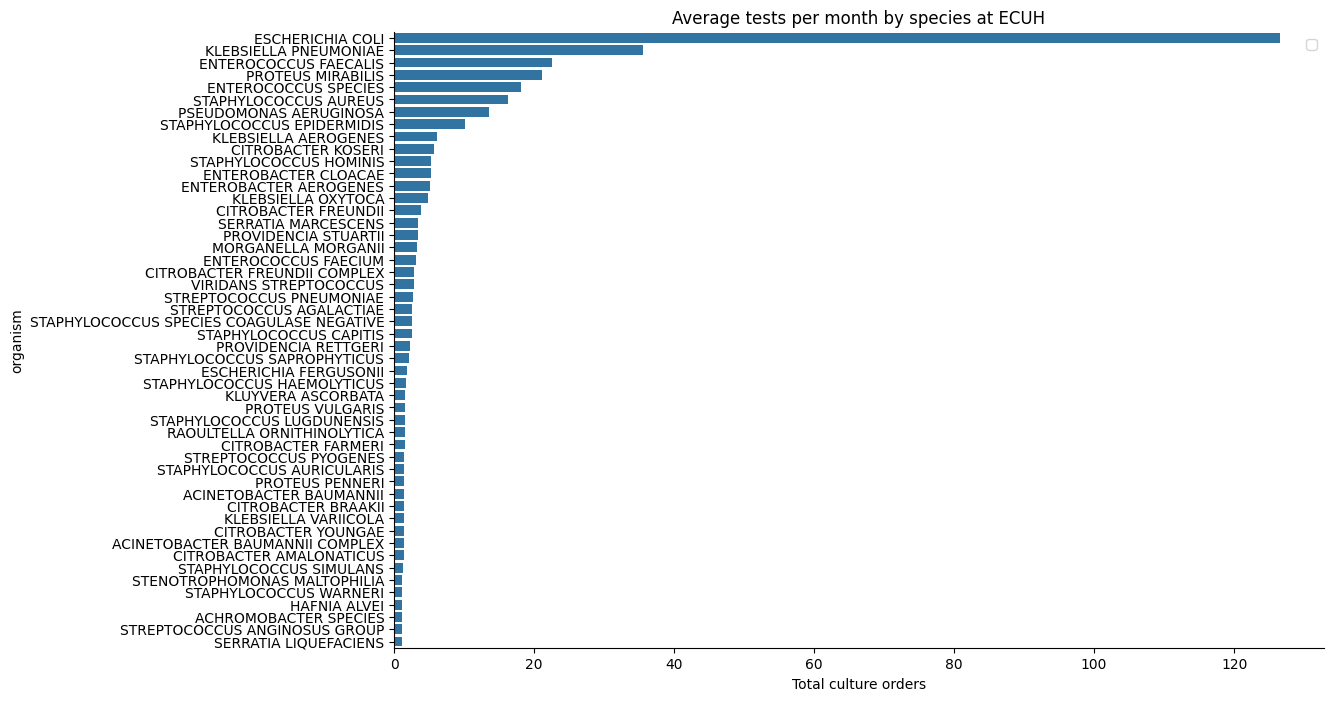

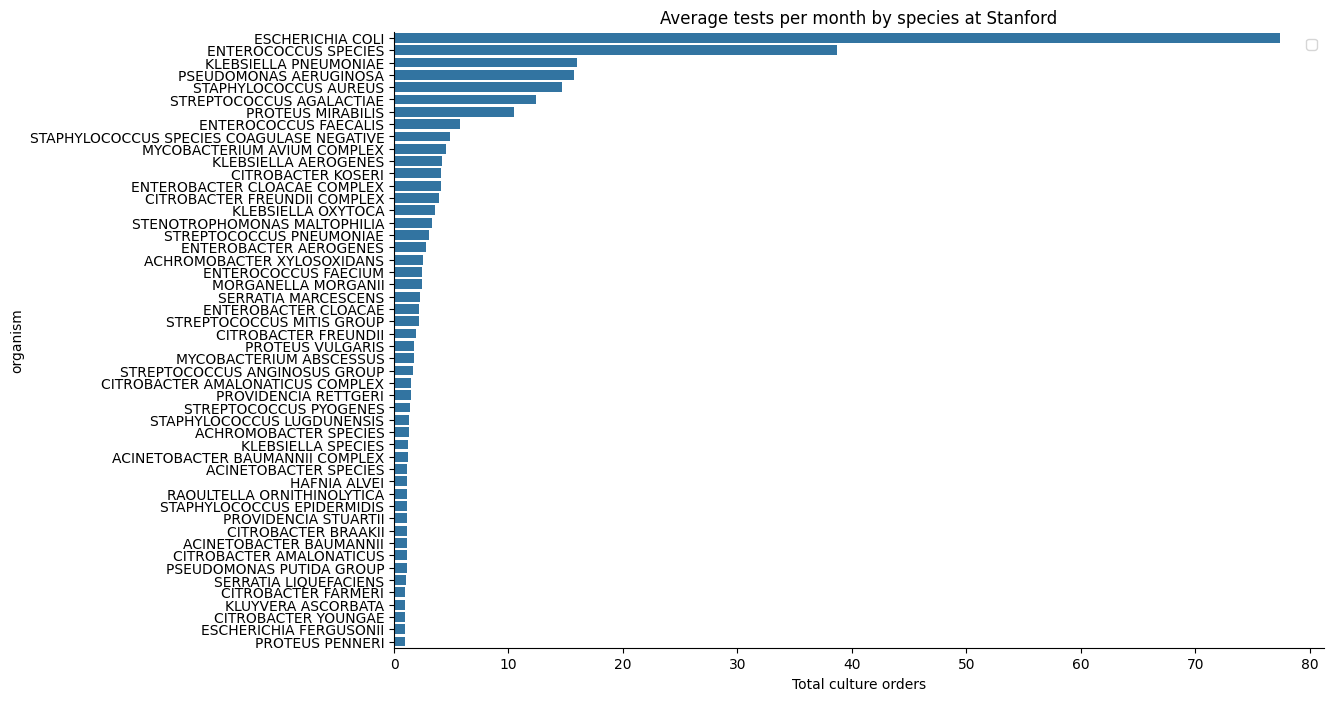

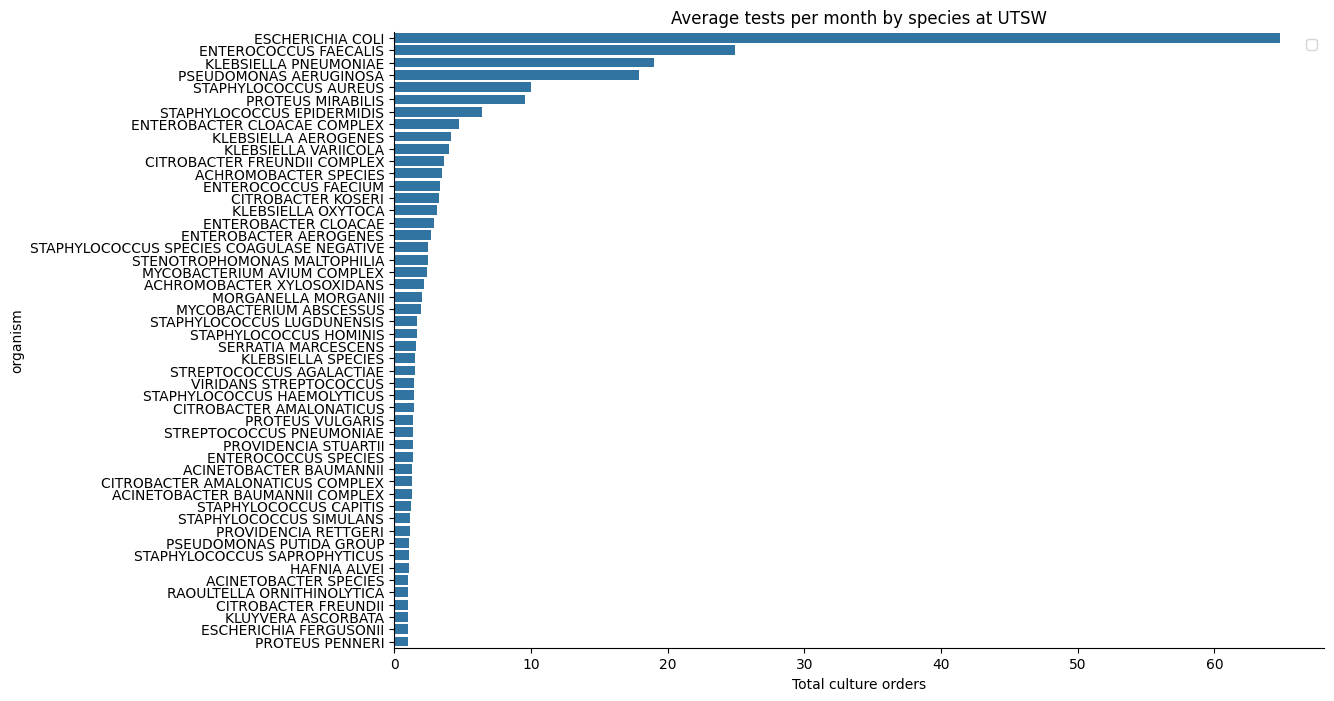

In [36]:
# Since most species have like 1-10 tests per month, I think I should sum the tests over 3 month intervals, also do the same for resistance, for less noisy training instances
biogram_sub = biogram.groupby(['organism','site'],as_index=False)['tested_count'].mean().sort_values(by='tested_count',ascending=False)

n = 50
for site in set(biogram_sub['site']):
    fig, ax = plt.subplots(figsize=(12, 8))
    biogram_sub_sub = biogram_sub[biogram_sub['site']==site].copy()
    biogram_sub_sub.drop_duplicates(subset='organism',inplace=True)
    sns.barplot(biogram_sub_sub.iloc[:n,:],x='tested_count',y='organism',ax=ax)
    ax.set_title(f'Average tests per month by species at {site}')
    ax.set_xlabel('Total culture orders')
    # ax.set_xscale('log')
    ax.legend()
    plt.show()

In [37]:
biogram['3mo_bin'] = pd.to_datetime(biogram['month_start']).dt.to_period('Q')
biogram_perQ = biogram.groupby(['3mo_bin','antibiotic','organism','site','culture_description'],as_index=False)[['tested_count','resistant_count']].sum()
print(biogram_perQ.shape)
biogram_perQ = pd.merge(biogram_perQ,biogram[['year','antibiotic','3mo_bin','PHARM_CLASS','PHARM_SUBCLASS']].drop_duplicates(),on=['antibiotic','3mo_bin'],how='left')
biogram_perQ['Resistant'] = biogram_perQ['resistant_count'] / biogram_perQ['tested_count']
biogram_perQ


(147838, 7)


,3mo_bin,antibiotic,organism,site,culture_description,tested_count,resistant_count,year,PHARM_CLASS,PHARM_SUBCLASS,Resistant
0,2006Q2,AMIKACIN,ACHROMOBACTER XYLOSOXIDANS,UTSW,RESPIRATORY,1,1,2006,AMINOGLYCOSIDE ANTIBIOTICS,Aminoglycoside Antibiotic,1.000
1,2006Q2,AMIKACIN,CITROBACTER FREUNDII COMPLEX,UTSW,URINE,1,0,2006,AMINOGLYCOSIDE ANTIBIOTICS,Aminoglycoside Antibiotic,0.000
2,2006Q2,AMIKACIN,ENTEROBACTER CLOACAE,UTSW,BLOOD,1,0,2006,AMINOGLYCOSIDE ANTIBIOTICS,Aminoglycoside Antibiotic,0.000
3,2006Q2,AMIKACIN,ESCHERICHIA COLI,UTSW,URINE,1,0,2006,AMINOGLYCOSIDE ANTIBIOTICS,Aminoglycoside Antibiotic,0.000
4,2006Q2,AMIKACIN,PSEUDOMONAS AERUGINOSA,UTSW,RESPIRATORY,8,3,2006,AMINOGLYCOSIDE ANTIBIOTICS,Aminoglycoside Antibiotic,0.375
...,...,...,...,...,...,...,...,...,...,...,...
147833,2025Q1,VANCOMYCIN,STAPHYLOCOCCUS LUGDUNENSIS,ECUH,BLOOD,1,0,2025,VANCOMYCIN ANTIBIOTICS AND DERIVATIVES,Glycopeptide Antibiotics,0.000
147834,2025Q1,VANCOMYCIN,STAPHYLOCOCCUS LUGDUNENSIS,ECUH,URINE,1,0,2025,VANCOMYCIN ANTIBIOTICS AND DERIVATIVES,Glycopeptide Antibiotics,0.000
147835,2025Q1,VANCOMYCIN,STREPTOCOCCUS PNEUMONIAE,ECUH,BLOOD,8,0,2025,VANCOMYCIN ANTIBIOTICS AND DERIVATIVES,Glycopeptide Antibiotics,0.000
147836,2025Q1,VANCOMYCIN,STREPTOCOCCUS PNEUMONIAE,ECUH,RESPIRATORY,1,0,2025,VANCOMYCIN ANTIBIOTICS AND DERIVATIVES,Glycopeptide Antibiotics,0.000


In [38]:
biogram = biogram_perQ.copy()

In [39]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelBinarizer

encoder = OneHotEncoder(handle_unknown='error', sparse_output=False)

sp_lineage['sp_input'] = sp_lineage['sp_input'].str.upper()
taxa_cols = ['sp_input','phylum','class','order','family','genus']
taxa_encoder = encoder.fit(sp_lineage[taxa_cols])
oldshape = biogram.shape
biogram = pd.merge(biogram,sp_lineage[taxa_cols],how='left',left_on='organism',right_on='sp_input')
newshape = biogram.shape
assert oldshape[0] == newshape[0], "Something went wrong with merge"
taxa_1hot = taxa_encoder.transform(biogram[taxa_cols])
assert taxa_1hot.shape[1] == len(set(sp_lineage[taxa_cols].values.flatten())), "Lineage 1hot did not map correctly to total levels"

abx_cols = ['antibiotic', 'PHARM_CLASS', 'PHARM_SUBCLASS']
unique_abx_combos = biogram[abx_cols].drop_duplicates()
abx_encoder = encoder.fit(unique_abx_combos)
abx_1hot = abx_encoder.transform(biogram[abx_cols])
assert abx_1hot.shape[1] == len(set(unique_abx_combos.values.flatten())), "Antibiotics and classes 1hot did not map correctly to total levels"

culture_types = biogram['culture_description'].drop_duplicates()
culture_1hot = LabelBinarizer().fit_transform(biogram['culture_description'])
assert culture_1hot.shape[1] == len(set(culture_types.values.flatten())), "Antibiotics and classes 1hot did not map correctly to total levels"

site_locs = np.vstack([cartesian_coords[site] for site in biogram['site'].values])

descrete_data = {'abx':abx_1hot,
      'taxa':taxa_1hot,
      'culture':culture_1hot,
      'site':site_locs
      }

for k,v in descrete_data.items():
    assert v.shape[0] == biogram.shape[0], f"1hot for {k} has incorrect row count"
    print(k,v.shape)

abx (147838, 113)
taxa (147838, 105)
culture (147838, 3)
site (147838, 3)


In [40]:
# def add_model_features(df, origin_month=biogram['3mo_bin'].min(),max_time=biogram['3mo_bin'].max()):
#     out = df.iloc[:,16].copy() # just take the first few cols for easier processing

#     # time should include absolute time
#     # season of the year it is.
#     month_index = (
#         (out['3mo_bin'].dt.year - origin_month.year) * 12
#         + (out['3mo_bin'].dt.month - origin_month.month)
#     )
#     time_scale_months = (max_time.year - origin_month.year) * 12 + (max_time.month - origin_month.month)
#     out['month_index_scaled'] = month_index / time_scale_months
#     out['month_sin'] = np.sin(2 * np.pi * out['3mo_bin'].dt.month / 4) # 4 b/c we are now working in quarters
#     out['month_cos'] = np.cos(2 * np.pi * out['3mo_bin'].dt.month / 4)

#     # scale number of tests ideally from 0-1, so it's on similar scale to other variables.
#     out_log_n = np.log1p(out['tested_count'])
#     u,std = out_log_n.mean(),out_log_n.std()
#     out['testedcount_scaled'] = (out_log_n - u) / std
#     return out

In [41]:
def add_model_features(df, validation_site="UTSW"):
    out = df.reset_index(drop=True).copy()

    # Quarter start; preserves row order
    out["month_start"] = pd.PeriodIndex(
        out["3mo_bin"], freq="Q"
    ).to_timestamp()

    train = out["site"].str.upper().ne(validation_site.upper())
    origin, end = out.loc[train, "month_start"].agg(["min", "max"])

    month_i = (
        (out["month_start"].dt.year - origin.year) * 12
        + out["month_start"].dt.month - origin.month
    )
    time_scale = max(
        1,
        (end.year - origin.year) * 12 + end.month - origin.month,
    )

    angle = 2 * np.pi * (out["month_start"].dt.month - 1) / 12
    log_n = np.log1p(out["tested_count"])
    mean_n, std_n = log_n[train].mean(), log_n[train].std(ddof=0)

    out["quarter_index"] = (
        out["month_start"].dt.year * 4
        + out["month_start"].dt.quarter - 1
    )
    out["month_index_scaled"] = month_i / time_scale
    out["month_sin"], out["month_cos"] = np.sin(angle), np.cos(angle)
    out["testedcount_scaled"] = (log_n - mean_n) / (std_n or 1)

    return out

In [42]:
model_df = add_model_features(biogram)
model_df

,3mo_bin,antibiotic,organism,site,culture_description,tested_count,resistant_count,year,PHARM_CLASS,PHARM_SUBCLASS,...,class,order,family,genus,month_start,quarter_index,month_index_scaled,month_sin,month_cos,testedcount_scaled
0,2006Q2,AMIKACIN,ACHROMOBACTER XYLOSOXIDANS,UTSW,RESPIRATORY,1,1,2006,AMINOGLYCOSIDE ANTIBIOTICS,Aminoglycoside Antibiotic,...,Betaproteobacteria,Burkholderiales,Alcaligenaceae,Achromobacter,2006-04-01,8025,-0.086957,1.0,6.123234e-17,-0.968432
1,2006Q2,AMIKACIN,CITROBACTER FREUNDII COMPLEX,UTSW,URINE,1,0,2006,AMINOGLYCOSIDE ANTIBIOTICS,Aminoglycoside Antibiotic,...,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Citrobacter,2006-04-01,8025,-0.086957,1.0,6.123234e-17,-0.968432
2,2006Q2,AMIKACIN,ENTEROBACTER CLOACAE,UTSW,BLOOD,1,0,2006,AMINOGLYCOSIDE ANTIBIOTICS,Aminoglycoside Antibiotic,...,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Enterobacter,2006-04-01,8025,-0.086957,1.0,6.123234e-17,-0.968432
3,2006Q2,AMIKACIN,ESCHERICHIA COLI,UTSW,URINE,1,0,2006,AMINOGLYCOSIDE ANTIBIOTICS,Aminoglycoside Antibiotic,...,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia,2006-04-01,8025,-0.086957,1.0,6.123234e-17,-0.968432
4,2006Q2,AMIKACIN,PSEUDOMONAS AERUGINOSA,UTSW,RESPIRATORY,8,3,2006,AMINOGLYCOSIDE ANTIBIOTICS,Aminoglycoside Antibiotic,...,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,2006-04-01,8025,-0.086957,1.0,6.123234e-17,0.140381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147833,2025Q1,VANCOMYCIN,STAPHYLOCOCCUS LUGDUNENSIS,ECUH,BLOOD,1,0,2025,VANCOMYCIN ANTIBIOTICS AND DERIVATIVES,Glycopeptide Antibiotics,...,Bacilli,Caryophanales,Staphylococcaceae,Staphylococcus,2025-01-01,8100,1.000000,0.0,1.000000e+00,-0.968432
147834,2025Q1,VANCOMYCIN,STAPHYLOCOCCUS LUGDUNENSIS,ECUH,URINE,1,0,2025,VANCOMYCIN ANTIBIOTICS AND DERIVATIVES,Glycopeptide Antibiotics,...,Bacilli,Caryophanales,Staphylococcaceae,Staphylococcus,2025-01-01,8100,1.000000,0.0,1.000000e+00,-0.968432
147835,2025Q1,VANCOMYCIN,STREPTOCOCCUS PNEUMONIAE,ECUH,BLOOD,8,0,2025,VANCOMYCIN ANTIBIOTICS AND DERIVATIVES,Glycopeptide Antibiotics,...,Bacilli,Lactobacillales,Streptococcaceae,Streptococcus,2025-01-01,8100,1.000000,0.0,1.000000e+00,0.140381
147836,2025Q1,VANCOMYCIN,STREPTOCOCCUS PNEUMONIAE,ECUH,RESPIRATORY,1,0,2025,VANCOMYCIN ANTIBIOTICS AND DERIVATIVES,Glycopeptide Antibiotics,...,Bacilli,Lactobacillales,Streptococcaceae,Streptococcus,2025-01-01,8100,1.000000,0.0,1.000000e+00,-0.968432


In [43]:
class ANPEpisodeDataset(torch.utils.data.Dataset):
    def __init__(self, x, rate, count_meta, resistant, tested, quarter, specs):
        self.x, self.rate, self.meta = x, rate, count_meta
        self.k, self.n, self.q, self.specs = resistant, tested, quarter, specs

    def __len__(self):
        return len(self.specs)

    def __getitem__(self, i):
        context, target, cutoff = self.specs[i]
        rel = lambda rows: ((self.q[rows] - cutoff) / 4).astype("float32")[:, None]
        T = lambda x: torch.as_tensor(x, dtype=torch.float32)

        return {
            "context_x": T(np.c_[self.x[context], rel(context)]),

            # Column 0: resistance rate
            # Column 1: scaled log1p(tested_count)
            "context_y": T(np.c_[
                self.rate[context],
                self.meta[context],
            ]),

            "target_x": T(np.c_[self.x[target], rel(target)]),

            # Used only by the posterior during training
            "target_y": T(np.c_[
                self.rate[target],
                self.meta[target],
            ]),

            # Raw counts used by the Beta-Binomial loss
            "target_resistant": T(self.k[target, None]),
            "target_tested": T(self.n[target, None]),

            "context_rows": torch.as_tensor(context),
            "target_rows": torch.as_tensor(target),
        }

In [44]:
def build_anp_datasets(
    df, descrete_data, model_df,
    validation_site="UTSW",
    min_focal=2, max_focal=12,
    min_aux=1, max_aux=6,
    forecast_quarters=4,
    seed=7,
):
    df, model_df = df.reset_index(drop=True), model_df.reset_index(drop=True)
    assert len(df) == len(model_df) == next(iter(descrete_data.values())).shape[0]

    # Features known for both historical and future points
    x = np.concatenate([
        *(np.asarray(descrete_data[k]) for k in ("abx", "taxa", "culture", "site")),
        model_df[["month_index_scaled", "month_sin", "month_cos"]].to_numpy(),
    ], axis=1).astype("float32")

    q = model_df["quarter_index"].to_numpy()
    rate = df["Resistant"].to_numpy(dtype="float32")
    meta = model_df["testedcount_scaled"].to_numpy(dtype="float32")
    k = df["resistant_count"].to_numpy(dtype="float32")
    n = df["tested_count"].to_numpy(dtype="float32")
    sites = df["site"].astype(str)
    rng = np.random.default_rng(seed)

    # All rows from each site, ordered by quarter
    history = {}
    for site, rows in df.groupby("site").groups.items():
        rows = np.asarray(list(rows))
        history[site] = rows[np.argsort(q[rows])]

    series_cols = ["site", "organism", "antibiotic", "culture_description"]

    def make_specs(is_test):
        keep = sites.str.upper().eq(validation_site.upper()) == is_test
        specs = []

        for key, rows in df.loc[keep].groupby(series_cols, sort=False).groups.items():
            rows = np.asarray(list(rows))
            rows = rows[np.argsort(q[rows])]

            if len(rows) != len(np.unique(q[rows])):
                raise ValueError(f"Duplicate rows for series-quarter: {key}")

            row_by_quarter = dict(zip(q[rows], rows))

            for start in q[rows]:
                target = np.array([
                    row_by_quarter.get(start + j, -1)
                    for j in range(forecast_quarters)
                ])
                previous = rows[q[rows] < start]

                if (target < 0).any() or len(previous) < min_focal:
                    continue

                # Most recent 2–12 observations from the focal series
                focal_n = rng.integers(
                    min_focal,
                    min(max_focal, len(previous)) + 1,
                )
                focal = previous[-focal_n:]

                # Same-site, same-organism, non-focal-series observations
                # restricted to the focal-history time range
                site_rows = history[key[0]]
                prior_site_rows = site_rows[q[site_rows] < start]

                pool = prior_site_rows[
                    (df.loc[prior_site_rows, "organism"].to_numpy() == key[1])
                    & (q[prior_site_rows] >= q[focal].min())
                    & ~np.isin(prior_site_rows, rows)
                ]

                if len(pool) < min_aux:
                    continue

                aux_n = rng.integers(
                    min_aux,
                    min(max_aux, len(pool)) + 1,
                )
                auxiliary = rng.choice(pool, size=aux_n, replace=False)

                context = np.r_[focal, auxiliary].astype(int)
                context = context[np.argsort(q[context])]

                assert q[context].max() < q[target].min()
                specs.append((context, target, start - 1))

        return specs

    train_specs = make_specs(is_test=False)
    test_specs = make_specs(is_test=True)

    # Explicitly verify that no UTSW rows appear in training episodes
    assert all(
        sites.iloc[np.r_[c, t]].str.upper().ne(validation_site.upper()).all()
        for c, t, _ in train_specs
    )

    arrays = (x, rate, meta, k, n, q)
    return (
        ANPEpisodeDataset(*arrays, train_specs),
        ANPEpisodeDataset(*arrays, test_specs),
    )



In [45]:
train_dataset, utsw_dataset = build_anp_datasets(
    biogram,
    descrete_data,
    model_df,
)

sample = train_dataset[0]

print("Number of training episodes:", len(train_dataset))
for name, value in sample.items():
    print(name, tuple(value.shape))

Number of training episodes: 64452
context_x (11, 228)
context_y (11, 2)
target_x (4, 228)
target_y (4, 2)
target_resistant (4, 1)
target_tested (4, 1)
context_rows (11,)
target_rows (4,)


In [46]:
cols = [
    "3mo_bin", "site", "organism", "antibiotic",
    "culture_description", "tested_count",
    "resistant_count", "Resistant",
]

print("CONTEXT")
display(biogram.iloc[sample["context_rows"].numpy()][cols])

print("TARGET")
display(biogram.iloc[sample["target_rows"].numpy()][cols])

CONTEXT


,3mo_bin,site,organism,antibiotic,culture_description,tested_count,resistant_count,Resistant
37742,2015Q3,ECUH,ACHROMOBACTER SPECIES,AZTREONAM,RESPIRATORY,1,1,1.0
44592,2016Q2,ECUH,ACHROMOBACTER SPECIES,AZTREONAM,RESPIRATORY,1,1,1.0
51460,2017Q1,ECUH,ACHROMOBACTER SPECIES,AZTREONAM,RESPIRATORY,2,2,1.0
53913,2017Q2,ECUH,ACHROMOBACTER SPECIES,AZTREONAM,RESPIRATORY,2,2,1.0
55418,2017Q2,ECUH,ACHROMOBACTER SPECIES,PIPERACILLIN/TAZOBACTAM,URINE,1,0,0.0
54317,2017Q2,ECUH,ACHROMOBACTER SPECIES,CEFTRIAXONE,RESPIRATORY,2,2,1.0
58660,2017Q4,ECUH,ACHROMOBACTER SPECIES,AZTREONAM,RESPIRATORY,2,2,1.0
60289,2017Q4,ECUH,ACHROMOBACTER SPECIES,TOBRAMYCIN,RESPIRATORY,2,1,0.5
63267,2018Q2,ECUH,ACHROMOBACTER SPECIES,AZTREONAM,RESPIRATORY,2,2,1.0
65519,2018Q3,ECUH,ACHROMOBACTER SPECIES,AZTREONAM,RESPIRATORY,1,1,1.0


TARGET


,3mo_bin,site,organism,antibiotic,culture_description,tested_count,resistant_count,Resistant
70401,2019Q1,ECUH,ACHROMOBACTER SPECIES,AZTREONAM,RESPIRATORY,1,0,0.0
72905,2019Q2,ECUH,ACHROMOBACTER SPECIES,AZTREONAM,RESPIRATORY,2,1,0.5
75456,2019Q3,ECUH,ACHROMOBACTER SPECIES,AZTREONAM,RESPIRATORY,4,4,1.0
78181,2019Q4,ECUH,ACHROMOBACTER SPECIES,AZTREONAM,RESPIRATORY,2,2,1.0


In [47]:
print("context_y [rate, scaled_log_tested]:")
print(sample["context_y"])

print("context_x shape:", sample["context_x"].shape)
print("target_x shape:", sample["target_x"].shape)

context_y [rate, scaled_log_tested]:
tensor([[ 1.0000, -0.9684],
        [ 1.0000, -0.9684],
        [ 1.0000, -0.6695],
        [ 1.0000, -0.6695],
        [ 0.0000, -0.9684],
        [ 1.0000, -0.6695],
        [ 1.0000, -0.6695],
        [ 0.5000, -0.6695],
        [ 1.0000, -0.6695],
        [ 1.0000, -0.9684],
        [ 1.0000, -0.9684]])
context_x shape: torch.Size([11, 228])
target_x shape: torch.Size([4, 228])


In [48]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
)

batch = next(iter(train_loader))

for name, value in batch.items():
    print(name, tuple(value.shape))

assert biogram.iloc[
    batch["context_rows"].flatten()
]["site"].str.upper().ne("UTSW").all()

context_x (1, 9, 228)
context_y (1, 9, 2)
target_x (1, 4, 228)
target_y (1, 4, 2)
target_resistant (1, 4, 1)
target_tested (1, 4, 1)
context_rows (1, 9)
target_rows (1, 4)


In [49]:
from torch.nn.utils.rnn import pad_sequence

def anp_collate(batch):
    lengths = torch.tensor([len(b["context_x"]) for b in batch])
    out = {}

    for key in batch[0]:
        values = [b[key] for b in batch]

        if key.startswith("context_"):
            pad_value = -1 if key == "context_rows" else 0
            out[key] = pad_sequence(
                values, batch_first=True, padding_value=pad_value
            )
        else:
            out[key] = torch.stack(values)

    out["context_padding_mask"] = (
        torch.arange(out["context_x"].shape[1])[None, :]
        >= lengths[:, None]
    )  # True = padding

    return out

In [50]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=anp_collate,
)

utsw_loader = torch.utils.data.DataLoader(
    utsw_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=anp_collate,
)

## Define the Attentive Neural Process

The architecture follows the reference ANP notebook conceptually, but uses current PyTorch APIs:

- `MLP` is a small feed-forward helper reused by the encoders and decoder.
- `DeterministicEncoder` converts context `(x, y)` pairs into representations and uses multi-head cross-attention so each target month can attend to relevant context months.
- `LatentEncoder` summarizes a task into a Gaussian latent variable `z`, which represents uncertainty over plausible future resistance trajectories.
- `Decoder` combines target-month features, attention output, and the latent sample to produce a Gaussian distribution over logit resistance rates.
- `AttentiveNeuralProcess.forward(...)` returns predictions plus training quantities: `mu`, `sigma`, `predictive`, `loss`, `log_prob`, and `kl`.

The model learns from many ECUH/Stanford organism-antibiotic curves, then applies that learned forecasting behavior to UTSW curves by conditioning on UTSW historical context.


In [51]:
# for beta-binomial
!pip -q install pyro-ppl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 21.2 MB/s eta 0:00:00


In [52]:
from pyro.distributions import BetaBinomial
from torch.distributions import Normal, kl_divergence

In [194]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        dims = [input_dim, *hidden_dims, output_dim]
        layers = []
        for i in range(len(dims)-1):
          if i < len(dims) - 2:
            lin_l = [nn.Linear(dims[i], dims[i + 1]), nn.ReLU()]
          else:
            lin_l = [nn.Linear(dims[i], dims[i + 1])]
          for layer in lin_l:
            layers.append(layer)
        self.net = nn.Sequential(*layers)
        # self.net = nn.Sequential(*[
        #     layer
        #     for i in range(len(dims) - 1)
        #     for layer in (
        #         [nn.Linear(dims[i], dims[i + 1]), nn.ReLU()]
        #         if i < len(dims) - 2
        #         else [nn.Linear(dims[i], dims[i + 1])]
        #     )
        # ])

    def forward(self, x):
        return self.net(x)

class DeterministicEncoder(nn.Module):
    def __init__(self, x_dim, context_y_dim=2, hidden_dim=128, num_heads=4):
        super().__init__()

        self.value_encoder = MLP(
            x_dim + context_y_dim,
            [hidden_dim, hidden_dim],
            hidden_dim,
        )

        # Attention weights depend only on context_x and target_x
        self.key_proj = nn.Linear(x_dim, hidden_dim)
        self.query_proj = nn.Linear(x_dim, hidden_dim)

        self.attention = nn.MultiheadAttention(
            hidden_dim,
            num_heads,
            batch_first=True,
        )
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, context_x, context_y, target_x, context_padding_mask=None):
        values = self.value_encoder(
            torch.cat([context_x, context_y], dim=-1)
        )

        keys = self.key_proj(context_x)
        queries = self.query_proj(target_x)

        attended, weights = self.attention(
            queries,
            keys,
            values,
            key_padding_mask=context_padding_mask,
            need_weights=True,
        )
        return self.norm(attended), weights


class LatentEncoder(nn.Module):
    def __init__(
        self,
        x_dim,
        context_y_dim=2,
        hidden_dim=128,
        latent_dim=64,
    ):
        super().__init__()

        self.encoder = MLP(
            x_dim + context_y_dim,
            [hidden_dim, hidden_dim],
            hidden_dim,
        )
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.raw_sigma = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x, y, padding_mask=None):
        encoded = self.encoder(torch.cat([x, y], dim=-1))

        if padding_mask is None:
            encoded = encoded.mean(dim=1)
        else:
            valid = (~padding_mask).unsqueeze(-1).to(encoded.dtype)
            encoded = (encoded * valid).sum(dim=1) / valid.sum(dim=1).clamp_min(1)

        mu = self.mu(encoded)
        sigma = 0.05 + F.softplus(self.raw_sigma(encoded))
        return Normal(mu, sigma)

class BetaBinomialDecoder(nn.Module):
    def __init__(
        self,
        x_dim,
        deterministic_dim=128,
        latent_dim=64,
        hidden_dim=128,
    ):
        super().__init__()

        self.net = MLP(
            x_dim + deterministic_dim + latent_dim,
            [hidden_dim, hidden_dim],
            2,
        )

    def forward(self, target_x, deterministic_rep, latent_sample):
        z = latent_sample[:, None, :].expand(
            -1,
            target_x.shape[1],
            -1,
        )

        output = self.net(torch.cat([ # concat all vecs into 1d then pass thru MLP
            target_x,
            deterministic_rep,
            z,
        ], dim=-1))

        mean_logit = output[..., :1] # the average rates in latent space?
        raw_concentration = output[..., 1:] # the 'uncertainty'

        mean_rate = torch.sigmoid(mean_logit).clamp( # turn the latent space rates into real rates, and make sure values don't go belore or below 0.0001 or above 0.9999
            1e-5,
            1 - 1e-5,
        )
        concentration = 2.0 + F.softplus(raw_concentration)

        alpha = mean_rate * concentration
        beta = (1 - mean_rate) * concentration

        return mean_rate, concentration, alpha, beta

class AttentiveNeuralProcess(nn.Module):
    def __init__(
        self,
        x_dim,
        context_y_dim=2,
        hidden_dim=128,
        latent_dim=64,
        num_heads=4,
    ):
        super().__init__()

        self.deterministic_encoder = DeterministicEncoder(
            x_dim,
            context_y_dim,
            hidden_dim,
            num_heads,
        )
        self.latent_encoder = LatentEncoder(
            x_dim,
            context_y_dim,
            hidden_dim,
            latent_dim,
        )
        self.decoder = BetaBinomialDecoder(
            x_dim,
            hidden_dim,
            latent_dim,
            hidden_dim,
        )

    def forward(
        self,
        context_x,
        context_y,
        target_x,
        target_y=None,
        target_resistant=None,
        target_tested=None,
        context_padding_mask=None,
    ):
        prior = self.latent_encoder(context_x, context_y, context_padding_mask) # a normal distribution computed using from the encoding of context_x and y
        # runs a few linear layers, then a separeate one for u (mu) and o (sigma), parameters to compute a normal distribution
        posterior = None

        # Target observations enter the posterior only during training
        if target_y is not None:
            posterior_mask = torch.cat([
                context_padding_mask,
                torch.zeros(
                    target_x.shape[:2],
                    dtype=torch.bool,
                    device=target_x.device,
                ),
            ], dim=1) # applying padding b/c some input lengths are different. Pads to max length
            posterior = self.latent_encoder(
                torch.cat([context_x, target_x], dim=1),
                torch.cat([context_y, target_y], dim=1),
                posterior_mask
            ) # does the samething as computing prior
            z = posterior.rsample() # shape = (batch_size,latent_dim)
        else:
            z = prior.rsample()

        deterministic_rep, attention_weights = (
            self.deterministic_encoder(
                context_x,
                context_y,
                target_x,
                context_padding_mask,
            )
        )

        mean_rate, concentration, alpha, beta = self.decoder(
            target_x,
            deterministic_rep,
            z,
        )

        output = {
            "mean_rate": mean_rate,
            "concentration": concentration,
            "alpha": alpha,
            "beta": beta,
            "attention_weights": attention_weights,
            'deterministic rep': deterministic_rep,
            "prior": prior,
            "posterior": posterior,
            "z":z,
            "prior":prior,
            "posterior":posterior
        }

        if target_tested is not None:
            target_tested = target_tested.round()
            predictive = BetaBinomial(
                concentration1=alpha,
                concentration0=beta,
                total_count=target_tested,
                validate_args=False,
            )
            output["predictive"] = predictive

            if target_resistant is not None:
                log_prob = predictive.log_prob(
                    target_resistant.round()
                ).mean() # can remove this to get the vector of log probabilities for all the timepoints in the forecast (which is currently a full year).

                loss = -log_prob
                kl = None

                if posterior is not None:
                    kl = kl_divergence(
                        posterior,
                        prior,
                    ).sum(dim=-1).mean() # small kl means that prior and psoterior are pretty similar,

                    loss = loss + kl / target_x.shape[1]

                output.update({
                    "loss": loss,
                    "log_prob": log_prob,
                    "kl": kl,
                })

        return output


In [87]:
batch = next(iter(train_loader))
if "context_meta" in batch:  # only for an old dataset object still in memory
    print('if called')
    batch["context_y"] = torch.cat([batch["context_y"], batch["context_meta"]], -1)
    batch["target_y"] = torch.cat([batch["target_y"], batch["target_meta"]], -1)
print(batch["context_x"].shape)  # [..., 228] # the 2nd dimension may look slightly different at each time b/c shuffle=true is on
print(batch["context_y"].shape)  # [..., 2]
batch['context_y'][2,:,:] # can see padding here. Might need to check that the loss doesn't try to average with the padded values since they are 0. Also hope it doesn't go into the loss.

torch.Size([64, 17, 228])
torch.Size([64, 17, 2])


tensor([[ 0.0000, -0.6695],
        [ 1.0000, -0.9684],
        [ 0.0000, -0.9684],
        [ 0.0000, -0.6695],
        [ 0.0000, -0.9684],
        [ 1.0000, -0.6695],
        [ 0.0000, -0.6695],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000]])

In [195]:
x_dim = train_dataset[0]["context_x"].shape[-1]

model = AttentiveNeuralProcess(
    x_dim=x_dim,
    context_y_dim=2,
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,

)

In [196]:
from time import perf_counter
from collections import deque

recent_losses = deque(maxlen=100)
recent_log_probs = deque(maxlen=100)
recent_kls = deque(maxlen=100)
recent_maes = deque(maxlen=100)
recent_concentrations = deque(maxlen=100)

MAX_STEPS = None  # smoke test; use None for all 68,244 episodes
PRINT_EVERY = 50
steps = min(len(train_loader), MAX_STEPS or len(train_loader))
model.train()
start = perf_counter()
print(f"Training {steps:,}/{len(train_loader):,} steps on {DEVICE}", flush=True)

for step, batch in enumerate(train_loader, 1):
    batch = {
        k: v.to(DEVICE)
        for k, v in batch.items() if k not in {"context_rows", "target_rows"}
    }

    # Supports an old dataset object still alive in the notebook kernel.
    if "context_meta" in batch:
        batch["context_y"] = torch.cat([batch["context_y"], batch["context_meta"]], -1)
        batch["target_y"] = torch.cat([batch["target_y"], batch["target_meta"]], -1)

    optimizer.zero_grad(set_to_none=True)
    output = model(
        context_x=batch["context_x"],
        context_y=batch["context_y"],
        target_x=batch["target_x"],
        target_y=batch["target_y"],
        target_resistant=batch["target_resistant"],
        target_tested=batch["target_tested"],
        context_padding_mask=batch["context_padding_mask"],
    )

    output["loss"].backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
    optimizer.step()

    recent_losses.append(output["loss"].item())
    recent_log_probs.append(output["log_prob"].item())
    recent_kls.append(output["kl"].item())
    recent_maes.append((output["mean_rate"].detach() - batch["target_y"][..., :1]).abs().mean().item())
    recent_concentrations.append(output["concentration"].detach().mean().item())

    if step == 1 or step % PRINT_EVERY == 0 or step == steps:
        print(
            f"step {step:,}/{steps:,} | "
            f"avg100 loss {np.mean(recent_losses):.4f} | "
            f"log_prob {np.mean(recent_log_probs):.4f} | "
            f"kl {np.mean(recent_kls):.4f} | "
            f"mae {np.mean(recent_maes):.4f} | "
            f"concentration {np.mean(recent_concentrations):.2f} | "
            f"grad_norm {grad_norm.item():.4f} | "
            f"{perf_counter() - start:.1f}s",
            flush=True,
        )
    if step >= steps:
        break
    # if step > 1:
    # break

print("Training cell finished.", flush=True)

Training 1,008/1,008 steps on cuda
step 1/1,008 | avg100 loss 2.9271 | log_prob -2.9271 | kl 0.0002 | mae 0.4208 | concentration 2.69 | grad_norm 3.3678 | 0.0s
step 50/1,008 | avg100 loss 1.8904 | log_prob -1.8893 | kl 0.0044 | mae 0.2239 | concentration 2.30 | grad_norm 3.9177 | 1.0s
step 100/1,008 | avg100 loss 1.7315 | log_prob -1.7297 | kl 0.0072 | mae 0.1798 | concentration 2.21 | grad_norm 1.0789 | 2.0s
step 150/1,008 | avg100 loss 1.4957 | log_prob -1.4929 | kl 0.0112 | mae 0.1237 | concentration 2.39 | grad_norm 1.0155 | 3.0s
step 200/1,008 | avg100 loss 1.3777 | log_prob -1.3753 | kl 0.0099 | mae 0.1032 | concentration 4.44 | grad_norm 2.9134 | 3.9s
step 250/1,008 | avg100 loss 1.2997 | log_prob -1.2976 | kl 0.0084 | mae 0.0919 | concentration 9.38 | grad_norm 0.9966 | 4.9s
step 300/1,008 | avg100 loss 1.2523 | log_prob -1.2504 | kl 0.0076 | mae 0.0876 | concentration 14.56 | grad_norm 5.8629 | 5.9s
step 350/1,008 | avg100 loss 1.2575 | log_prob -1.2559 | kl 0.0063 | mae 0.086

In [182]:
print(output.keys())
print('mean rate and input shapes:',output['mean_rate'].shape,batch['context_x'].shape,batch['context_y'].shape)
print('example pred mean rate,:',output['mean_rate'][0,:,:])
print('target shapes:',batch['target_x'].shape)
print('z:',output['z'].shape)
print('attention_rep:',output['deterministic rep'].shape)
print('attention_weights:',output['attention_weights'].shape)


dict_keys(['mean_rate', 'concentration', 'alpha', 'beta', 'attention_weights', 'deterministic rep', 'prior', 'posterior', 'z', 'predictive', 'loss', 'log_prob', 'kl'])
mean rate and input shapes: torch.Size([4, 4, 1]) torch.Size([4, 16, 228]) torch.Size([4, 16, 2])
example pred mean rate,: tensor([[0.0464],
        [0.0454],
        [0.0474],
        [0.0486]], device='cuda:0', grad_fn=<SelectBackward0>)
target shapes: torch.Size([4, 4, 228])
z: torch.Size([4, 64])
attention_rep: torch.Size([4, 4, 128])
attention_weights: torch.Size([4, 4, 16])


In [183]:
pd.DataFrame(output['attention_weights'][0,:,:].detach().cpu().numpy())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.024270,0.029255,0.046652,2.525957e-07,0.028023,0.052667,0.045628,0.057722,3.369536e-07,0.096923,0.111884,0.098847,0.045525,0.130413,0.005204,0.226984
1,0.024236,0.029560,0.046685,5.412379e-07,0.029058,0.052161,0.045611,0.058210,7.306966e-07,0.096811,0.110475,0.098015,0.048970,0.129948,0.006213,0.224046
2,0.019166,0.025387,0.041900,6.707774e-07,0.026849,0.045259,0.039707,0.055172,8.679474e-07,0.096460,0.106532,0.094713,0.055029,0.137239,0.006548,0.250038
3,0.018217,0.024201,0.040718,2.722073e-07,0.025408,0.044261,0.038511,0.053914,3.570819e-07,0.096363,0.107313,0.095063,0.050783,0.139549,0.005253,0.260446


In [184]:
batch['context_y'][0,:,:]

tensor([[ 0.0000, -0.1585],
        [ 0.0000,  0.2181],
        [ 0.0000,  0.5170],
        [ 0.0208,  1.8931],
        [ 0.0000,  0.8935],
        [ 0.0000,  0.4115],
        [ 0.0000,  0.0536],
        [ 0.0000,  0.1404],
        [ 0.1364,  0.8321],
        [ 0.0000, -0.2929],
        [ 0.0000,  0.0536],
        [ 0.0000, -0.0449],
        [ 0.0000, -0.0449],
        [ 0.0000, -0.1585],
        [ 0.0000, -0.1585],
        [ 0.1111,  0.2181]], device='cuda:0')

In [186]:
pd.DataFrame(output['deterministic rep'][0,:,:].detach().cpu().numpy())

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.886432,-0.663069,0.969567,-0.127247,0.960180,-0.239560,2.444192,1.077672,1.540196,-1.850785,...,-1.614049,1.505582,0.950439,2.385733,-1.083858,0.382272,1.883944,0.710924,-0.812754,0.793366
1,0.886577,-0.662265,0.969458,-0.126537,0.958850,-0.237055,2.442775,1.076067,1.540724,-1.851398,...,-1.613844,1.505607,0.949832,2.385707,-1.081802,0.383557,1.886321,0.712648,-0.814686,0.790983
2,0.912347,-0.666193,0.957012,-0.146676,0.936466,-0.235446,2.453575,1.061364,1.544635,-1.861740,...,-1.620014,1.495186,0.937560,2.378207,-1.089004,0.397506,1.904627,0.713360,-0.820912,0.794869
3,0.918008,-0.669031,0.954058,-0.151589,0.932749,-0.238432,2.457176,1.059902,1.544783,-1.863124,...,-1.621156,1.492419,0.935466,2.376977,-1.093840,0.399651,1.905935,0.711359,-0.819554,0.798580


In [55]:
for step, batch in enumerate(train_loader, 1):
    batch = {
        k: v.to(DEVICE)
        for k, v in batch.items() if k not in {"context_rows", "target_rows"}
    }

    # Supports an old dataset object still alive in the notebook kernel.
    if "context_meta" in batch:
        batch["context_y"] = torch.cat([batch["context_y"], batch["context_meta"]], -1)
        batch["target_y"] = torch.cat([batch["target_y"], batch["target_meta"]], -1)
    break

prior_x, prior_y = batch["context_x"], batch["context_y"]
post_x = torch.cat([batch["context_x"], batch["target_x"]], dim=1)
post_y = torch.cat([batch["context_y"], batch["target_y"]], dim=1)

with torch.no_grad():
    prior = model.latent_encoder(prior_x, prior_y)
    posterior = model.latent_encoder(post_x, post_y)

print("Input shapes:", prior_x.shape, prior_y.shape, post_x.shape, post_y.shape)
print("Mean |μ difference|:", (prior.loc - posterior.loc).abs().mean().item())
print("Mean |σ difference|:", (prior.scale - posterior.scale).abs().mean().item())
print("KL:", kl_divergence(posterior, prior).sum(-1).mean().item())
print("First 5 prior μ/σ:", prior.loc[0, :5], prior.scale[0, :5])
print("First 5 posterior μ/σ:", posterior.loc[0, :5], posterior.scale[0, :5])

NameError: name 'model' is not defined

In [112]:
import torch
import pandas as pd

with torch.no_grad():
  # Toy feature vectors for four future quarters.
  # These are illustrative numbers, not your notebook's actual feature encoding.
  target_x = torch.tensor([[
      [0.1, 1.0, 0.0],
      [0.2, 1.0, 0.0],
      [0.3, 1.0, 0.0],
      [0.4, 1.0, 0.0],
  ]])  # (1, 4, 3)

  # Pretend these came from your deterministic attention encoder.
  deterministic_rep = torch.tensor([[
      [0.2, 0.8],
      [0.3, 0.7],
      [0.4, 0.6],
      [0.5, 0.5],
  ]])  # (1, 4, 2)

  # Pretend this was sampled from your latent encoder's distribution.
  latent_sample = torch.tensor([[0.6, -0.2]])  # (1, 2)
  z = latent_sample[:, None, :].expand(-1, target_x.shape[1], -1)
  print('z:',z,z.shape)


  combined = torch.cat([target_x, deterministic_rep, z], dim=-1)
  print('combined raw target, deterministic rep, and z:',combined,combined.shape)

  toy_decoder = BetaBinomialDecoder(
      x_dim=3, deterministic_dim=2, latent_dim=2, hidden_dim=8
  )
  raw = toy_decoder.net(combined)
  print('raw decoder outputs:',raw,raw.shape)
  mean_logit,uncertainty = raw[...,0], raw[...,1:]
  print('mean_logit correct',mean_logit)
  print('incorrect mean logit1:',raw[:,0])
  print('incorrect mean logit2:',raw[...,0])

  print('test mean rate',torch.sigmoid(mean_logit))



# with torch.no_grad():
#     # Step 1: Repeat the SAME latent vector for all four quarters.
#     z = latent_sample[:, None, :].expand(-1, target_x.shape[1], -1)

#     # Step 2: Join the three inputs along their feature dimension.
#     combined = torch.cat([target_x, deterministic_rep, z], dim=-1)

#     # Step 3: The MLP produces two unconstrained numbers per quarter.
#     raw = toy_decoder.net(combined)

    # Step 4: Run your actual forward() to transform those numbers.
  mean_rate, concentration, alpha, beta = toy_decoder(
      target_x, deterministic_rep, latent_sample
  )
  print('mean rate:',mean_rate)

# print("Repeated latent vectors:\n", z)
# print("\nCombined shape:", combined.shape)  # (1, 4, 7)
# print("Quarter 1 combined input:", combined[0, 0])
# # tensor([0.1, 1.0, 0.0, 0.2, 0.8, 0.6, -0.2])

# display(pd.DataFrame({
#     "quarter": [1, 2, 3, 4],
#     "mean_logit": raw[0, :, 0].numpy(),
#     "raw_concentration": raw[0, :, 1].numpy(),
#     "mean_rate": mean_rate.flatten().numpy(),
#     "concentration": concentration.flatten().numpy(),
#     "alpha": alpha.flatten().numpy(),
#     "beta": beta.flatten().numpy(),
# }))

z: tensor([[[ 0.6000, -0.2000],
         [ 0.6000, -0.2000],
         [ 0.6000, -0.2000],
         [ 0.6000, -0.2000]]]) torch.Size([1, 4, 2])
combined raw target, deterministic rep, and z: tensor([[[ 0.1000,  1.0000,  0.0000,  0.2000,  0.8000,  0.6000, -0.2000],
         [ 0.2000,  1.0000,  0.0000,  0.3000,  0.7000,  0.6000, -0.2000],
         [ 0.3000,  1.0000,  0.0000,  0.4000,  0.6000,  0.6000, -0.2000],
         [ 0.4000,  1.0000,  0.0000,  0.5000,  0.5000,  0.6000, -0.2000]]]) torch.Size([1, 4, 7])
raw decoder outputs: tensor([[[ 0.0013, -0.1633],
         [ 0.0006, -0.1603],
         [-0.0003, -0.1605],
         [-0.0011, -0.1606]]]) torch.Size([1, 4, 2])
mean_logit correct tensor([[ 0.0013,  0.0006, -0.0003, -0.0011]])
incorrect mean logit1: tensor([[ 0.0013, -0.1633]])
incorrect mean logit2: tensor([[ 0.0013,  0.0006, -0.0003, -0.0011]])
test mean rate tensor([[0.5003, 0.5002, 0.4999, 0.4997]])
mean rate: tensor([[[0.5003],
         [0.5002],
         [0.4999],
         [0.499

In [197]:
def evaluate_loader(loader, mc_samples=20):
    model.eval()
    results = []

    with torch.inference_mode():
        for batch in loader:
            target_rows = batch["target_rows"].reshape(-1).numpy()

            batch = {
                k: v.to(DEVICE)
                for k, v in batch.items()
                if k not in {"context_rows", "target_rows"}
            }

            if "context_meta" in batch:
                batch["context_y"] = torch.cat(
                    [batch["context_y"], batch["context_meta"]], -1
                )
                batch["target_y"] = torch.cat(
                    [batch["target_y"], batch["target_meta"]], -1
                )

            predictions, log_probs = [], []

            # Average multiple prior samples for more stable evaluation
            for _ in range(mc_samples):
                output = model(
                    context_x=batch["context_x"],
                    context_y=batch["context_y"],
                    target_x=batch["target_x"],
                    target_resistant=batch["target_resistant"],
                    target_tested=batch["target_tested"],
                    context_padding_mask=batch["context_padding_mask"],
                    # Do not pass target_y during evaluation
                )

                predictions.append(output["mean_rate"])
                log_probs.append(
                    output["predictive"].log_prob(
                        batch["target_resistant"].round()
                    )
                )

            pred = torch.stack(predictions).mean(0)
            log_prob = (
                torch.logsumexp(torch.stack(log_probs), dim=0)
                - np.log(mc_samples)
            )

            metadata = biogram.reset_index(drop=True).iloc[target_rows][[
                "site", "organism", "antibiotic",
                "culture_description", "3mo_bin", "tested_count"
            ]].reset_index(drop=True)

            metadata["horizon"] = np.tile(
                np.arange(1, batch["target_x"].shape[1] + 1),
                batch["target_x"].shape[0],
            )
            metadata["true_rate"] = (
                batch["target_y"][..., 0].reshape(-1).cpu().numpy()
            )
            metadata["pred_rate"] = pred.reshape(-1).cpu().numpy()
            metadata["nll"] = -log_prob.reshape(-1).cpu().numpy()
            metadata["abs_error"] = (
                metadata["true_rate"] - metadata["pred_rate"]
            ).abs()

            results.append(metadata)

    return pd.concat(results, ignore_index=True)


eval_df = evaluate_loader(utsw_loader)

print(f"MAE: {eval_df['abs_error'].mean() * 100:.2f} percentage points")
print(f"NLL: {eval_df['nll'].mean():.3f}")

MAE: 9.96 percentage points
NLL: 1.518


In [63]:
eval_df

,site,organism,antibiotic,culture_description,3mo_bin,tested_count,horizon,true_rate,pred_rate,nll,abs_error
0,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q1,3,1,1.000000,0.323273,3.078703,0.676727
1,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q2,21,2,0.952381,0.333609,10.235598,0.618772
2,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q3,17,3,0.941176,0.319622,9.390064,0.621555
3,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q4,22,4,1.000000,0.306046,14.407658,0.693954
4,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q2,21,1,0.952381,0.565371,4.155054,0.387010
...,...,...,...,...,...,...,...,...,...,...,...
101351,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q3,5,4,0.000000,0.000565,0.002742,0.000565
101352,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q1,2,1,0.000000,0.000507,0.001004,0.000507
101353,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q2,4,2,0.000000,0.000439,0.001714,0.000439
101354,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q3,5,3,0.000000,0.000495,0.002399,0.000495


In [64]:
eval_df["3mo_bin"].dt.to_timestamp()

,3mo_bin
0,2019-01-01
1,2019-04-01
2,2019-07-01
3,2019-10-01
4,2019-04-01
...,...
101351,2009-07-01
101352,2009-01-01
101353,2009-04-01
101354,2009-07-01


In [65]:
# plt_df = eval_df.groupby(['horizon','organism','3mo_bin','culture_description'],as_index=False)[['abs_error','nll']].mean()
# plt_df['3mo_bin'] = plt_df["3mo_bin"].dt.to_timestamp()
# g = sns.FacetGrid(plt_df, col="culture_description",row="organism", height=2.5)
# g.map(sns.barplot, x='3mo_bin',y='abs_error')

In [66]:
eval_df[
    eval_df['organism'].eq('ACHROMOBACTER SPECIES')
    & eval_df['antibiotic'].eq('AMIKACIN')
    & eval_df['3mo_bin'].eq('2019Q1')
]

,site,organism,antibiotic,culture_description,3mo_bin,tested_count,horizon,true_rate,pred_rate,nll,abs_error
0,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q1,3,1,1.0,0.323273,3.078703,0.676727


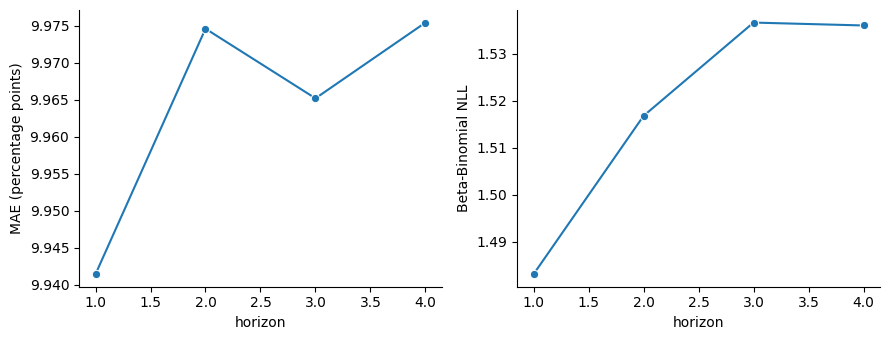

In [198]:
metrics = eval_df.groupby("horizon", as_index=False).agg(
    MAE=("abs_error", "mean"),
    NLL=("nll", "mean"),
)
metrics["MAE"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
sns.lineplot(metrics, x="horizon", y="MAE", marker="o", ax=axes[0])
sns.lineplot(metrics, x="horizon", y="NLL", marker="o", ax=axes[1])
axes[0].set_ylabel("MAE (percentage points)")
axes[1].set_ylabel("Beta-Binomial NLL")
plt.tight_layout()

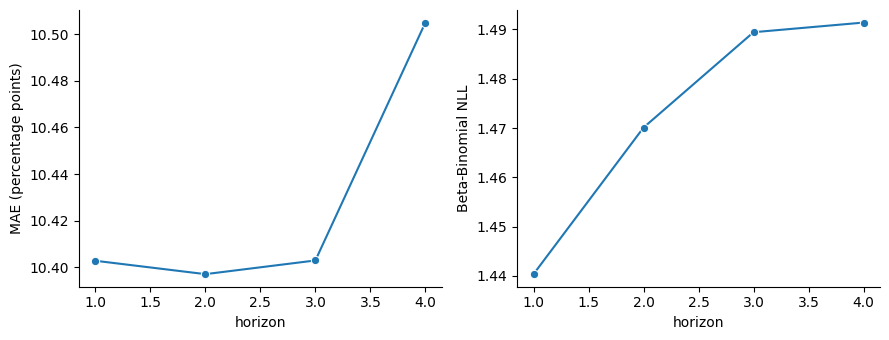

In [193]:
metrics = eval_df.groupby("horizon", as_index=False).agg( # below is from loss = (log_prob + kl) / target_x.shape[0]
    MAE=("abs_error", "mean"),
    NLL=("nll", "mean"),
)
metrics["MAE"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
sns.lineplot(metrics, x="horizon", y="MAE", marker="o", ax=axes[0])
sns.lineplot(metrics, x="horizon", y="NLL", marker="o", ax=axes[1])
axes[0].set_ylabel("MAE (percentage points)")
axes[1].set_ylabel("Beta-Binomial NLL")
plt.tight_layout()

In [68]:
def plot_organism_forecast(
    organism,
    start,
    end,
    n_antibiotics=4,
    horizon=1,
    culture=None,
    predictions=None,
    eval_df=eval_df,
):
    d = (eval_df if predictions is None else predictions).copy()
    d["date"] = (
          d["3mo_bin"].dt.to_timestamp()
          if isinstance(d["3mo_bin"].dtype, pd.PeriodDtype)
          else pd.to_datetime(d["3mo_bin"])
      )

    d = d[
        d["organism"].astype(str).str.casefold().eq(organism.casefold())
        & d["date"].between(pd.to_datetime(start), pd.to_datetime(end))
        & d["horizon"].eq(horizon)
    ].copy()

    if d.empty:
        raise ValueError("No matching predictions in eval_df.")

    if culture is None:
        culture = (
            d.groupby("culture_description")["tested_count"]
            .sum()
            .idxmax()
        )

    d = d[
        d["culture_description"].astype(str).str.casefold()
        .eq(str(culture).casefold())
    ]

    top_antibiotics = (
        d.groupby("antibiotic")["tested_count"]
        .sum()
        .nlargest(n_antibiotics)
        .index
    )

    d = d[d["antibiotic"].isin(top_antibiotics)].sort_values("date")

    plot_df = d.melt(
        id_vars=["date", "antibiotic"],
        value_vars=["true_rate", "pred_rate"],
        var_name="series",
        value_name="resistance_rate",
    )

    g = sns.relplot(
        data=plot_df,
        x="date",
        y="resistance_rate",
        hue="series",
        style="series",
        col="antibiotic",
        col_wrap=2,
        kind="line",
        markers=True,
        dashes=False,
        estimator=None,
        ci=None,                 # use instead of errorbar=None
        facet_kws={"sharey": False},
        height=3,
    )

    g.set_titles("{col_name}")
    g.set_axis_labels("", "Resistance rate")
    g.fig.suptitle(
        f"{organism} — {culture}; forecast horizon={horizon}",
        y=1.03,
    )

    return d

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


,site,organism,antibiotic,culture_description,3mo_bin,tested_count,horizon,true_rate,pred_rate,nll,abs_error,date
31416,UTSW,ESCHERICHIA COLI,CIPROFLOXACIN,URINE,2019Q1,650,1,0.287692,0.215093,5.407543,0.072599,2019-01-01
32700,UTSW,ESCHERICHIA COLI,GENTAMICIN,URINE,2019Q1,650,1,0.127692,0.080941,5.111850,0.046751,2019-01-01
31944,UTSW,ESCHERICHIA COLI,ERTAPENEM,URINE,2019Q1,650,1,0.000000,0.005193,0.805640,0.005193,2019-01-01
36308,UTSW,ESCHERICHIA COLI,TOBRAMYCIN,URINE,2019Q1,650,1,0.090769,0.048368,5.169867,0.042401,2019-01-01
31420,UTSW,ESCHERICHIA COLI,CIPROFLOXACIN,URINE,2019Q2,716,1,0.279330,0.209961,5.458867,0.069368,2019-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...
31488,UTSW,ESCHERICHIA COLI,CIPROFLOXACIN,URINE,2023Q3,869,1,0.283084,0.199492,5.930310,0.083592,2023-07-01
32020,UTSW,ESCHERICHIA COLI,ERTAPENEM,URINE,2023Q4,826,1,0.001211,0.006658,2.057056,0.005447,2023-10-01
31492,UTSW,ESCHERICHIA COLI,CIPROFLOXACIN,URINE,2023Q4,827,1,0.275695,0.196593,5.794961,0.079102,2023-10-01
32776,UTSW,ESCHERICHIA COLI,GENTAMICIN,URINE,2023Q4,826,1,0.140436,0.078313,5.855309,0.062123,2023-10-01


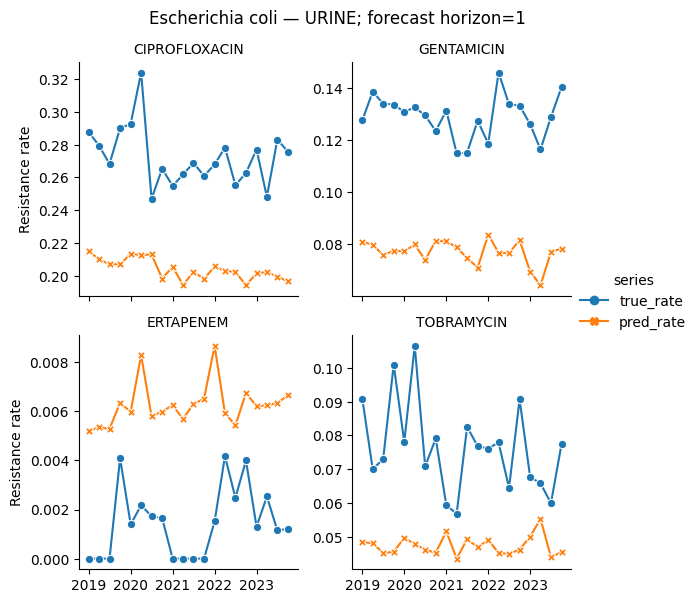

In [69]:
plot_organism_forecast(
    organism="Escherichia coli",
    start="2019-01-01",
    end="2023-12-31",
    # context_len=8,
    n_antibiotics=4,
    horizon=1,

)

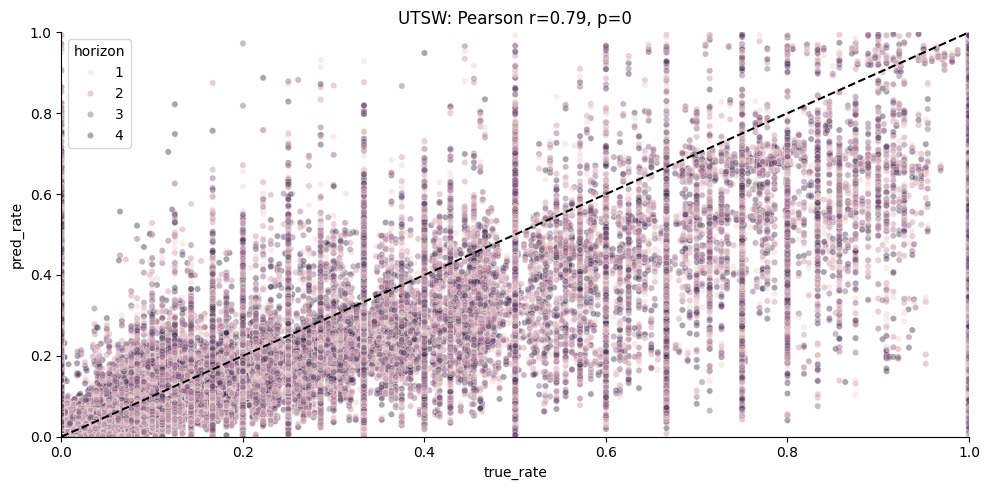

In [70]:
from scipy.stats import pearsonr

d = eval_df.dropna(subset=["true_rate", "pred_rate"])
r, p = pearsonr(d["true_rate"], d["pred_rate"])

ax = sns.scatterplot(
    data=d,
    x="true_rate",
    y="pred_rate",
    hue="horizon",
    alpha=0.4,
    s=20,
)

limits = [
    min(d["true_rate"].min(), d["pred_rate"].min()),
    max(d["true_rate"].max(), d["pred_rate"].max()),
]
ax.plot(limits, limits, "--", color="black")
ax.set(xlim=limits, ylim=limits)
ax.set_title(f"UTSW: Pearson r={r:.2f}, p={p:.2g}")
plt.tight_layout()

In [71]:
def make_fixed_context_loader(
    dataset,
    df, #supplies the row metadata
    context_len,
    aux_context_len=0,
    batch_size=64,
):
    if not isinstance(context_len, (int, np.integer)) or context_len < 1:
        raise ValueError("context_len must be a positive integer.")
    if not isinstance(aux_context_len, (int, np.integer)) or aux_context_len < 0:
        raise ValueError("aux_context_len must be a nonnegative integer.")

    d = df.reset_index(drop=True)
    q = dataset.q

    series_cols = [
        "site", "organism", "antibiotic", "culture_description"
    ]
    series_values = {
        col: d[col].astype(str).to_numpy()
        for col in series_cols
    }

    fixed_specs = []

    for _, target, cutoff in dataset.specs:
        first_target = int(target[0])

        same_series = np.ones(len(d), dtype=bool)
        for col in series_cols:
            same_series &= (
                series_values[col] == series_values[col][first_target]
            )

        previous = np.flatnonzero(
            same_series & (q < q[first_target])
        )
        previous = previous[np.argsort(q[previous], kind="stable")]

        if len(previous) < context_len:
            continue

        focal = previous[-context_len:]

        # Same site and organism, but outside the focal series
        auxiliary_pool = np.flatnonzero(
            (series_values["site"] == series_values["site"][first_target])
            & (series_values["organism"] == series_values["organism"][first_target])
            & ~same_series
            & (q >= q[focal].min())
            & (q < q[first_target])
        )

        if len(auxiliary_pool) < aux_context_len:
            continue

        auxiliary_pool = auxiliary_pool[
            np.argsort(q[auxiliary_pool], kind="stable")
        ]
        auxiliary = (
            auxiliary_pool[-aux_context_len:]
            if aux_context_len else np.array([], dtype=int)
        )

        context = np.concatenate([focal, auxiliary]).astype(int)
        context = context[np.argsort(q[context], kind="stable")]
        fixed_specs.append((context, np.asarray(target, dtype=int), cutoff))

    if not fixed_specs:
        raise ValueError("No episodes have enough focal and auxiliary context.")

    fixed_dataset = ANPEpisodeDataset(
        dataset.x, dataset.rate, dataset.meta,
        dataset.k, dataset.n, dataset.q, fixed_specs,
    )

    fixed_loader = torch.utils.data.DataLoader(
        fixed_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=anp_collate,
    )

    return fixed_dataset, fixed_loader

In [72]:
utsw_fixed_dataset, utsw_fixed_loader = make_fixed_context_loader(
    utsw_dataset,
    biogram,
    context_len=8,
    aux_context_len=3,
)

eval_df_fixed = evaluate_loader(utsw_fixed_loader)

In [73]:
eval_df_fixed

,site,organism,antibiotic,culture_description,3mo_bin,tested_count,horizon,true_rate,pred_rate,nll,abs_error
0,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2020Q3,7,1,0.857143,0.698459,1.487473,0.158684
1,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2020Q4,9,2,0.666667,0.700123,1.887698,0.033456
2,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2021Q1,9,3,1.000000,0.697429,1.850216,0.302571
3,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2021Q2,12,4,0.666667,0.694088,2.109601,0.027421
4,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2020Q4,9,1,0.666667,0.702290,1.882006,0.035624
...,...,...,...,...,...,...,...,...,...,...,...
87423,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q3,5,4,0.000000,0.000486,0.002357,0.000486
87424,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q1,2,1,0.000000,0.000497,0.000978,0.000497
87425,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q2,4,2,0.000000,0.000432,0.001693,0.000432
87426,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q3,5,3,0.000000,0.000486,0.002357,0.000486


/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


,site,organism,antibiotic,culture_description,3mo_bin,tested_count,horizon,true_rate,pred_rate,nll,abs_error,date
26700,UTSW,ESCHERICHIA COLI,CIPROFLOXACIN,URINE,2019Q1,650,1,0.287692,0.218342,5.353272,0.069350,2019-01-01
27864,UTSW,ESCHERICHIA COLI,GENTAMICIN,URINE,2019Q1,650,1,0.127692,0.081364,5.097886,0.046329,2019-01-01
27168,UTSW,ESCHERICHIA COLI,ERTAPENEM,URINE,2019Q1,650,1,0.000000,0.006159,0.960287,0.006159,2019-01-01
31184,UTSW,ESCHERICHIA COLI,TOBRAMYCIN,URINE,2019Q1,650,1,0.090769,0.056853,4.813110,0.033916,2019-01-01
26704,UTSW,ESCHERICHIA COLI,CIPROFLOXACIN,URINE,2019Q2,716,1,0.279330,0.216082,5.359936,0.063248,2019-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...
26772,UTSW,ESCHERICHIA COLI,CIPROFLOXACIN,URINE,2023Q3,869,1,0.283084,0.198838,5.945498,0.084246,2023-07-01
27244,UTSW,ESCHERICHIA COLI,ERTAPENEM,URINE,2023Q4,826,1,0.001211,0.006425,2.047954,0.005214,2023-10-01
26776,UTSW,ESCHERICHIA COLI,CIPROFLOXACIN,URINE,2023Q4,827,1,0.275695,0.199896,5.728532,0.075799,2023-10-01
27940,UTSW,ESCHERICHIA COLI,GENTAMICIN,URINE,2023Q4,826,1,0.140436,0.082172,5.697616,0.058263,2023-10-01


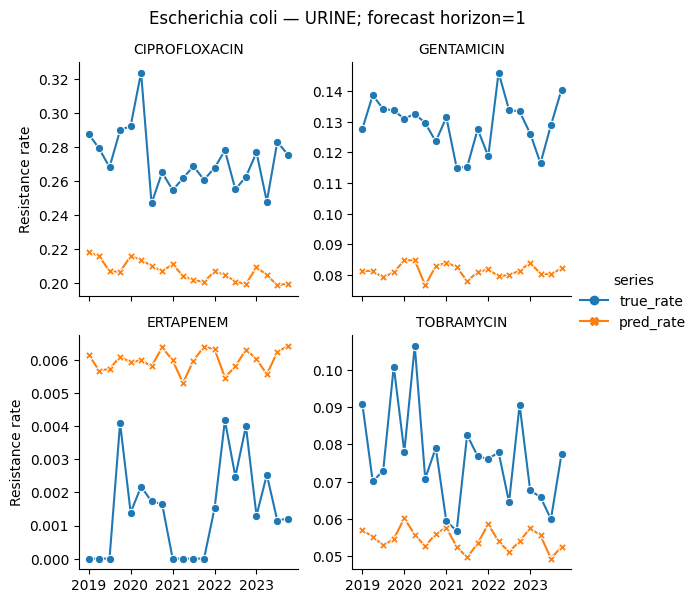

In [74]:
plot_organism_forecast(
    organism="Escherichia coli",
    start="2019-01-01",
    end="2023-12-31",
    # context_len=8,
    n_antibiotics=4,
    horizon=1,
    predictions=eval_df_fixed,

)

In [77]:
for i in range(0,16,4):
  if i == 0:
    i+=1
  print(i)
  utsw_fixed_dataset, utsw_fixed_loader = make_fixed_context_loader(
      utsw_dataset,
      biogram,
      context_len=i,
      aux_context_len=4,
  )

  eval_df_fixed = evaluate_loader(utsw_fixed_loader)
  eval_df_fixed.to_csv(f'eval_df_fixed_context{i}_auxcontext4.tsv',sep="\t")

1
4
8
12


In [79]:
# score on absolute directionality? Like if true resistance inc from t1 -> t2 does predicted resistance do the same?
utsw_dataset


In [78]:
eval_df

,site,organism,antibiotic,culture_description,3mo_bin,tested_count,horizon,true_rate,pred_rate,nll,abs_error
0,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q1,3,1,1.000000,0.323273,3.078703,0.676727
1,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q2,21,2,0.952381,0.333609,10.235598,0.618772
2,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q3,17,3,0.941176,0.319622,9.390064,0.621555
3,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q4,22,4,1.000000,0.306046,14.407658,0.693954
4,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q2,21,1,0.952381,0.565371,4.155054,0.387010
...,...,...,...,...,...,...,...,...,...,...,...
101351,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q3,5,4,0.000000,0.000565,0.002742,0.000565
101352,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q1,2,1,0.000000,0.000507,0.001004,0.000507
101353,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q2,4,2,0.000000,0.000439,0.001714,0.000439
101354,UTSW,VIRIDANS STREPTOCOCCUS,VANCOMYCIN,BLOOD,2009Q3,5,3,0.000000,0.000495,0.002399,0.000495


In [86]:
eval_diff_contexts = []
for i in range(0,16,4):
  if i == 0:
    i+=1
  df = pd.read_csv(f'eval_df_fixed_context{i}_auxcontext4.tsv',sep="\t",index_col=0)
  df['context_len'] = str(i)
  eval_diff_contexts.append(df)

eval_diff_contexts = pd.concat(eval_diff_contexts)
eval_diff_contexts

,site,organism,antibiotic,culture_description,3mo_bin,tested_count,horizon,true_rate,pred_rate,nll,abs_error,context_len
0,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q1,3,1,1.000000,0.090036,6.640897,0.909964,1
1,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q2,21,2,0.952381,0.092839,26.480110,0.859542,1
2,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q3,17,3,0.941176,0.089664,22.993286,0.851513,1
3,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q4,22,4,1.000000,0.085588,32.176212,0.914412,1
4,UTSW,ACHROMOBACTER SPECIES,AMIKACIN,RESPIRATORY,2019Q2,21,1,0.952381,0.686758,2.657189,0.265623,1
...,...,...,...,...,...,...,...,...,...,...,...,...
77275,UTSW,VIRIDANS STREPTOCOCCUS,PENICILLIN,BLOOD,2016Q4,2,4,0.000000,0.008611,0.017154,0.008611,12
77276,UTSW,VIRIDANS STREPTOCOCCUS,PENICILLIN,BLOOD,2017Q2,3,1,0.000000,0.006541,0.019367,0.006541,12
77277,UTSW,VIRIDANS STREPTOCOCCUS,PENICILLIN,BLOOD,2017Q3,2,2,0.000000,0.007051,0.014035,0.007051,12
77278,UTSW,VIRIDANS STREPTOCOCCUS,PENICILLIN,BLOOD,2017Q4,3,3,0.000000,0.007848,0.023250,0.007848,12


In [92]:
eval_diff_contexts['3mo_bin'] = pd.to_datetime(eval_diff_contexts['3mo_bin'])
eval_diff_contexts['year'] = eval_diff_contexts['3mo_bin'].dt.year

eval_diff_contexts_avgerror = eval_diff_contexts.groupby(['culture_description','year','context_len'],as_index=False)['abs_error'].mean()

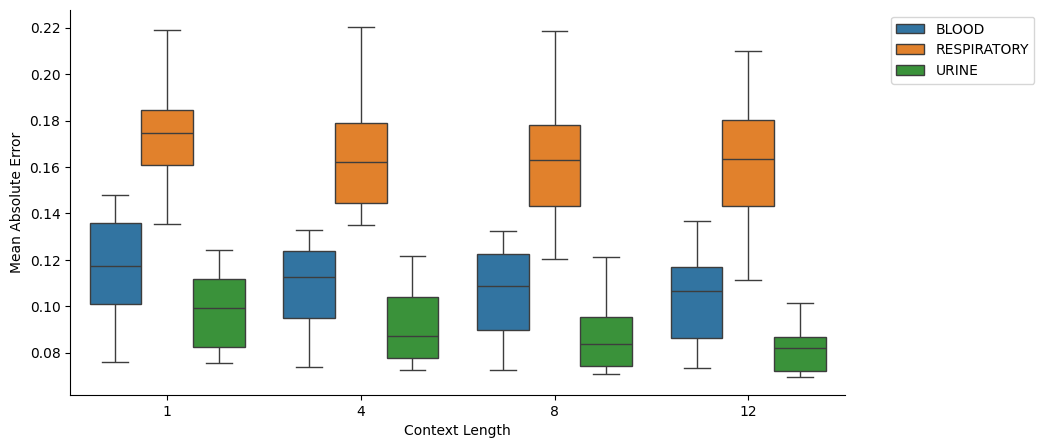

In [94]:
import seaborn as sns

sns.boxplot(eval_diff_contexts_avgerror,x='context_len',y='abs_error',hue='culture_description',showfliers=False)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.ylabel("Mean Absolute Error")
plt.xlabel("Context Length")
plt.show()

In [ ]:
# compare gram + v. gram -
# for gram - look at esbl and carbapenem for ecoli, klebp, proteus mirabilis, and pseudamonas aeruginosa
# plot organism level staph aureus and enterococcus faecium
# vanc, amp, penicillin

In [97]:
from scipy.stats import mannwhitneyu
from itertools import combinations
ctype = 'RESPIRATORY'
sub = eval_diff_contexts_avgerror[eval_diff_contexts_avgerror['culture_description']==ctype]
context_combos = list(combinations(sub['context_len'].unique(),2))
for combo in context_combos:
  u,p = mannwhitneyu(sub[sub['context_len']==combo[0]]['abs_error'].values,sub[sub['context_len']==combo[1]]['abs_error'].values)
  print(combo,p)


('1', '4') 0.255140625810503
('1', '8') 0.16493153959832263
('1', '12') 0.175039875738077
('4', '8') 0.7267523671056437
('4', '12') 0.8492110007400978
('8', '12') 0.8819307212779461


In [98]:
ctype = 'URINE'
sub = eval_diff_contexts_avgerror[eval_diff_contexts_avgerror['culture_description']==ctype]
context_combos = list(combinations(sub['context_len'].unique(),2))
for combo in context_combos:
  u,p = mannwhitneyu(sub[sub['context_len']==combo[0]]['abs_error'].values,sub[sub['context_len']==combo[1]]['abs_error'].values)
  print(combo,p)

('1', '4') 0.14788989971136035
('1', '8') 0.02173493050953741
('1', '12') 0.009168501285614451
('4', '8') 0.32336189874714527
('4', '12') 0.08705765959380804
('8', '12') 0.49865925804988187


In [99]:
ctype = 'BLOOD'
sub = eval_diff_contexts_avgerror[eval_diff_contexts_avgerror['culture_description']==ctype]
context_combos = list(combinations(sub['context_len'].unique(),2))
for combo in context_combos:
  u,p = mannwhitneyu(sub[sub['context_len']==combo[0]]['abs_error'].values,sub[sub['context_len']==combo[1]]['abs_error'].values)
  print(combo,p)

('1', '4') 0.18199590852786351
('1', '8') 0.1321657102574444
('1', '12') 0.06978127016578495
('4', '8') 0.5534865685531849
('4', '12') 0.42825079969504054
('8', '12') 0.5635436160789709


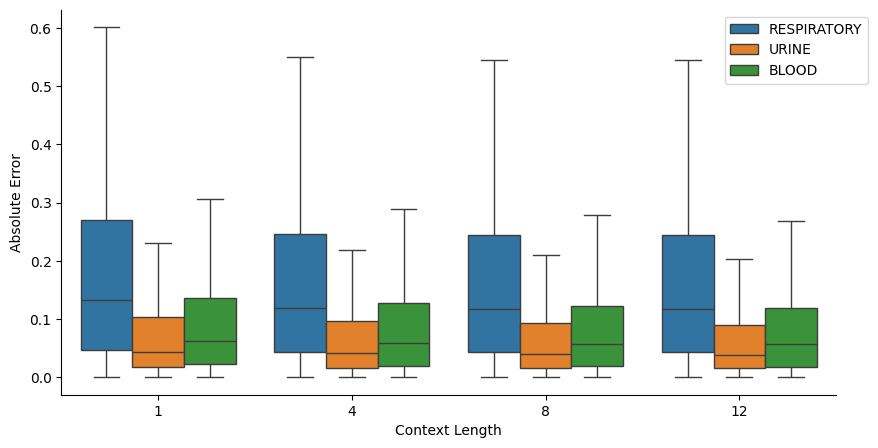

In [100]:

sns.boxplot(eval_diff_contexts,x='context_len',y='abs_error',hue='culture_description',showfliers=False)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.ylabel("Absolute Error")
plt.xlabel("Context Length")
plt.show()